<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/%22Module1Task%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 1. Аналітика продажів**

Набір **Synthetic E-Commerce Relational Dataset** є синтетичним (згенерованим) e-commerce датасетом у реляційному форматі, що складається з п’яти пов’язаних таблиць: **Customers** (профілі клієнтів), **Products** (каталог товарів), **Orders** (факти замовлень), **Order Items** (позиції всередині замовлень) і **Product Reviews** (відгуки), де зв’язки між сутностями реалізовані через ключі на кшталт `customer_id`, `product_id`, `order_id`, що дозволяє відтворити типову схему “клієнт - замовлення - позиції” та прив’язати відгуки до конкретних товарів і авторів. Датасет містить базові атрибути клієнта (ім’я, email, стать, дата реєстрації, країна), характеристики товарів (назва, категорія, бренд, ціна, залишки), транзакційні поля замовлення (дата, загальна сума, метод оплати, країна доставки) та деталі позицій (кількість, ціна на момент покупки)

https://www.kaggle.com/datasets/naelaqel/synthetic-e-commerce-relational-dataset

**Огляд таблиць даних**

### 1. Customers

* **customer_id (int):** унікальний ідентифікатор для кожного клієнта
* **name (string):** повне ім’я клієнта
* **email (string):** електронна адреса клієнта
* **gender (string):** стать клієнта ('Male', 'Female', 'Other')
* **signup_date (date):** дата реєстрації клієнта
* **country (string):** країна проживання клієнта

### 2. Products

* **product_id (int):** унікальний ідентифікатор для кожного продукту
* **product_name (string):** назва продукту
* **category (string):** категорія продукту (наприклад, Electronics, Books)
* **price (float):** ціна за одиницю
* **stock_quantity (int):** доступна кількість на складі
* **brand (string):** назва бренду продукту

### 3. Orders

* **order_id (int):** унікальний ідентифікатор для кожного замовлення
* **customer_id (int):** ідентифікатор клієнта, який зробив замовлення (зовнішній ключ до Customers)
* **order_date (date):** дата оформлення замовлення
* **total_amount (float):** загальна сума замовлення
* **payment_method (string):** використаний метод оплати (Credit Card, PayPal тощо)
* **shipping_country (string):** країна, куди відправляється замовлення

### 4. Order Items

* **order_item_id (int):** унікальний ідентифікатор для кожної позиції в замовленні
* **order_id (int):** ідентифікатор замовлення, до якого належить позиція (зовнішній ключ до Orders)
* **product_id (int):** ідентифікатор замовленого продукту (зовнішній ключ до Products)
* **quantity (int):** кількість замовлених одиниць
* **unit_price (float):** ціна за одиницю на момент замовлення

### 5. Product Reviews

* **review_id (int):** унікальний ідентифікатор для кожного відгуку
* **product_id (int):** ідентифікатор продукту, на який залишено відгук (зовнішній ключ до Products)
* **customer_id (int):** ідентифікатор клієнта, який написав відгук (зовнішній ключ до Customers)
* **rating (int):** оцінка (від 1 до 5)
* **review_text (string):** текст відгуку
* **review_date (date):** дата написання відгуку


## План аналізу
1. **Групування даних**.

2. **Інженерія ознак**.

3. **EDA та візуалізації**.




Схема даних має вигляд

![picture](https://drive.google.com/uc?id=1tLZSOpyEjwFOJT5JnN1btnaRumSkr-DY)


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
from pathlib import Path

pd.set_option("display.max_columns", 70)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 70)

print("✅ Бібліотеки успішно імпортовано")

✅ Бібліотеки успішно імпортовано


#**Групування даних**

**Мета** — отримати **надійний** і **зрозумілий** датафрейм для аналізу, де можна довіряти підсумкам. Валідація merge захищає від “тихих” помилок (коли рядки непомітно розмножуються або зникають), статистики й IQR допомагають побачити типові значення та аномалії, а коректна робота з пропусками робить результати EDA/моделей стабільнішими. У підсумку ми перетворюємо сирі таблиці на підготовлену основу для бізнес-інсайтів, дашбордингу або навчання моделей.

**План**
1. Завантаження та агрегування даних.
2. Перетворення типів даних.
3. Об'єднання в одну таблицю даних.
4. Обчислення базових статистик.
5. Визначення викидів та заповнення пропусків.

Результатом цього заняття буде сформована таблиця даних, готова для подальшого аналізу.








##**Завантаження даних з Kaggle**

Оскільки оригінальний набір даних знаходиться на kaggle.com - kagglehub, використаємо стандартні засоби перенесення у Google Colab. Notebook'и в Colab та Kaggle трохи відрізняються, але це насправді один і той самих формат - Jupyter Notebook.

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("naelaqel/synthetic-e-commerce-relational-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'synthetic-e-commerce-relational-dataset' dataset.
Path to dataset files: /kaggle/input/synthetic-e-commerce-relational-dataset


In [11]:
# # IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# # THEN FEEL FREE TO DELETE THIS CELL.
# # NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# # ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# # NOTEBOOK.
# import kagglehub
# data_path = kagglehub.dataset_download('naelaqel/synthetic-e-commerce-relational-dataset','./')

# print('Data source import complete.')


Стандартний код Kaggle для перегляду змісту набору даних, який після імпорту знаходиться в директорії /kaggle/input

In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import gc

import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 70)

pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 70)



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/csv/customers.csv
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/csv/products.csv
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/csv/product_reviews.csv
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/csv/order_items.csv
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/csv/orders.csv
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/parquet/orders.parquet
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/parquet/customers.parquet
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7/parquet/product_reviews.parquet
/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions

Завантаження даних з окремих csv файлів з перевіркою наявності файлів. В результаті всі дані завантажуються у словник data, де ключами є назви відповідних таблиць

In [13]:
import pandas as pd
from pathlib import Path

# --- paths ---
base = Path("/root/.cache/kagglehub/datasets/naelaqel/synthetic-e-commerce-relational-dataset/versions/7")
parquet_dir = base / "parquet"

# --- dataframe name -> parquet path ---
df_paths = {
    "df_customers": parquet_dir / "customers.parquet",
    "df_products": parquet_dir / "products.parquet",
    "df_orders": parquet_dir / "orders.parquet",
    "df_order_items": parquet_dir / "order_items.parquet",
    "df_product_reviews": parquet_dir / "product_reviews.parquet",
}

# --- read all into a dict: dataframe name -> DataFrame ---
dfs = {name: pd.read_parquet(path) for name, path in df_paths.items()}

# quick check
{n: df.shape for n, df in dfs.items()}

{'df_customers': (2000000, 6),
 'df_products': (20000, 6),
 'df_orders': (8000000, 6),
 'df_order_items': (20000000, 5),
 'df_product_reviews': (4000000, 6)}

##Набори даних

Вивід на друк окремих файлів даних. Можна продивитись окремі колонки та конкретні дані. Це дозволить візуально зрозуміти, з якими даними ми будемо далі працювати.

In [14]:
display(dfs['df_customers'])

,customer_id,name,email,gender,signup_date,country
0,1,Allison Hill,donaldgarcia@example.net,Other,2025-02-15,Benin
1,2,Amanda Davis,williamjohnson@example.org,Male,2024-03-30,Reunion
2,3,Connie Lawrence,blakeerik@example.com,Male,2022-05-13,Cape Verde
3,4,Phillip Garcia,wdavis@example.net,Other,2021-12-26,Aruba
4,5,Kimberly Dudley,smiller@example.net,Female,2023-10-04,Tokelau
...,...,...,...,...,...,...
1999995,1999996,Maria Thomas,casey50@example.com,Male,2020-09-03,Bulgaria
1999996,1999997,Teresa Michael,robin41@example.net,Other,2025-08-11,Faroe Islands
1999997,1999998,Jasmine Richardson,mirandakristin@example.net,Male,2021-04-25,Saint Kitts and Nevis
1999998,1999999,April Baldwin,renee53@example.net,Other,2022-09-15,Pakistan


In [15]:
display(dfs['df_products'])

,product_id,product_name,category,price,stock_quantity,brand
0,1,Plan Get,Books,278.27,533,BrandA
1,2,Field Yet,Beauty,479.56,5,BrandA
2,3,Technology Her,Books,332.59,268,BrandA
3,4,Decade Pick,Toys,198.16,944,BrandB
4,5,Finally Develop,Beauty,307.60,862,BrandC
...,...,...,...,...,...,...
19995,19996,Similar Pull,Toys,441.76,955,BrandC
19996,19997,Really Least,Toys,346.40,112,BrandD
19997,19998,Thing Apply,Beauty,361.73,335,BrandB
19998,19999,Early Stock,Electronics,157.90,570,BrandD


In [16]:
display(dfs['df_orders'])

,order_id,customer_id,order_date,total_amount,payment_method,shipping_country
0,1,331090,2025-05-12,774.46,Credit Card,Pakistan
1,2,208473,2022-12-31,757.80,Bank Transfer,Liechtenstein
2,3,847096,2021-09-19,2355.87,Credit Card,Sri Lanka
3,4,1919911,2024-10-21,776.77,Credit Card,Sri Lanka
4,5,281685,2024-10-26,0.00,Cash,Costa Rica
...,...,...,...,...,...,...
7999995,7999996,1105016,2024-03-26,2264.31,Cash,Sudan
7999996,7999997,974479,2022-09-12,1994.11,Bank Transfer,Nicaragua
7999997,7999998,92076,2024-07-20,2112.11,Credit Card,Portugal
7999998,7999999,1461391,2023-12-07,3519.03,Bank Transfer,Algeria


In [17]:
display(dfs['df_order_items'])

,order_item_id,order_id,product_id,quantity,unit_price
0,1,6373838,4999,4,498.31
1,2,831217,19254,5,298.43
2,3,4870008,14862,2,404.92
3,4,6105609,9893,5,225.24
4,5,5466713,17378,4,10.23
...,...,...,...,...,...
19999995,19999996,4162804,5676,3,162.83
19999996,19999997,5104680,9336,4,204.58
19999997,19999998,2109816,16779,5,340.98
19999998,19999999,6094516,9083,5,282.06


In [18]:
display(dfs['df_product_reviews'])

,review_id,product_id,customer_id,rating,review_text,review_date
0,1,6133,1800986,4,Represent indeed tax moment form hear difference believe role hard.,2025-08-04
1,2,3154,383956,3,Down note local marriage threat address hundred blood near.,2022-04-05
2,3,13907,1445167,2,Interview know prevent director coach next.,2022-10-24
3,4,11575,1809449,1,Their skill toward must catch organization expert parent drive.,2023-04-09
4,5,11948,670817,1,Charge respond medical hundred take can three.,2025-04-18
...,...,...,...,...,...,...
3999995,3999996,2677,350996,5,Dream single turn address summer college admit.,2022-06-12
3999996,3999997,11384,1466767,5,Another reality matter ready able indeed age deal company.,2021-09-24
3999997,3999998,19981,1733710,1,Answer word group remember travel factor hot page black.,2025-01-21
3999998,3999999,7310,1586062,5,Contain old defense drop talk data early large agreement weight in...,2023-08-12


Отже, ми розглянули всі таблиці даних, які є в цьому наборі. Далі необхідно виконати перетворення даних, зокрема, для того, щоб дата та час були правильних типів.

Виконаємо ці перетворення далі.

##**Перетворення типів (дати + переклад категорій)**

### Перетворення дат

Стовпці з датою/часом є в таблицях **df_customers**, **df_orders**, **df_product_review**. Це стовпці  

"signup_date"

"order_date",

"review_date"






Перетворення в тип `datetime`

In [19]:
df_customers        = dfs["df_customers"]
df_products         = dfs["df_products"]
df_orders           = dfs["df_orders"]
df_order_items      = dfs["df_order_items"]
df_product_reviews  = dfs["df_product_reviews"]

# dates
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], errors="coerce")
df_customers["signup_date"] = pd.to_datetime(df_customers["signup_date"], errors="coerce")
df_product_reviews["review_date"] = pd.to_datetime(df_product_reviews["review_date"], errors="coerce")



Перетворення категорійних даних в тип `category`

https://pandas.pydata.org/docs/user_guide/categorical.html

In [20]:
# categoricals (економія пам'яті)
for c in ["payment_method", "shipping_country"]:
    df_orders[c] = df_orders[c].astype("category")

for c in ["category", "brand"]:
    df_products[c] = df_products[c].astype("category")

for c in ["gender", "country"]:
    df_customers[c] = df_customers[c].astype("category")

## **Агрегації даних**

Функції `groupby()` та `agg()` є ключовими під час збирання даних з різних таблиць, тому що вони дозволяють привести “сирі” транзакційні записи до потрібного рівня аналізу перед об’єднанням і після нього. Через `groupby()` ми визначаємо одиницю спостереження (наприклад, замовлення, клієнт, день), а `agg()` перетворює множину рядків на компактні, інтерпретовані показники: суми, середні, кількість, частки, максимум/мінімум, кількість унікальних значень тощо. Це робить можливим коректне злиття таблиць з різною гранулярністю (item-level, payment-level, review-level, order-level або customer-level), зменшує ризик дублювання рядків і “роздування” даних при `merge()`, а також формує узгоджену аналітичну таблицю, придатну для EDA, побудови ознак і подальшого моделювання.


При для агрегація доречно створювати тимчасові структури даних та команди del та gc.collect() для звільнення пам'яті, коли тимчасові структури вже не потрібні

Наприклад



```python
# великий тимчасовий датафрейм
tmp = pd.DataFrame({
    "x": np.random.randn(3_000_000),
    "y": np.random.randint(0, 100, size=3_000_000)
})

# отримали потрібний результат
result = tmp.groupby("y", observed=True)["x"].mean().reset_index()

# tmp більше не потрібен → звільняємо пам'ять
del tmp
gc.collect()

result.head()
```




### Агрегація даних на рівні клієнта (customer-level)

Для аналізу поведінки клієнтів агрегуємо дані з `df_order_level` до рівня одного клієнта.
Кожен рядок результату відповідає одному клієнту та містить:
- `n_orders` — загальна кількість замовлень
- `total_spent` — загальна сума витрат
- `avg_order_value` — середній чек
- `first_order_date` / `last_order_date` — перше та останнє замовлення
- `days_active` — кількість днів між першим і останнім замовленням
- `avg_rating` — середній рейтинг товарів у замовленнях клієнта

In [38]:
# Агрегація customers - customer-level
customer_agg = (
    df_order_level.groupby("customer_id", observed=True)
    .agg(
        n_orders=("order_id", "size"),
        total_spent=("total_amount", "sum"),
        avg_order_value=("total_amount", "mean"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        n_unique_countries=("shipping_country", "nunique"),
        avg_items_per_order=("n_lines", "mean"),
        total_qty=("total_qty", "sum"),
        avg_rating=("product_rating_mean_w", "mean"),
    )
    .reset_index()
)

customer_agg["days_active"] = (
    customer_agg["last_order_date"] - customer_agg["first_order_date"]
).dt.days

print("✅ customer_agg:", customer_agg.shape)
customer_agg.head()

✅ customer_agg: (1963340, 11)


,customer_id,n_orders,total_spent,avg_order_value,first_order_date,last_order_date,n_unique_countries,avg_items_per_order,total_qty,avg_rating,days_active
0,1,4,4198.82,1049.705000,2023-02-03,2024-10-18,4,2.333333,16.0,2.983459,623
1,2,4,8461.77,2115.442500,2022-11-28,2025-07-06,4,2.333333,26.0,3.027774,951
2,4,8,12426.16,1553.270000,2022-05-14,2025-08-27,8,2.142857,41.0,3.003558,1201
3,6,4,6453.53,1613.382500,2022-08-12,2023-07-09,4,2.500000,35.0,2.983307,331
4,7,7,23559.96,3365.708571,2021-09-21,2024-09-30,7,3.571429,84.0,2.952871,1105


In [23]:
pr = df_product_reviews[["product_id", "rating"]].copy()

product_review_agg = (
    pr.groupby("product_id", observed=True)
      .agg(
          product_review_cnt=("rating", "size"),
          product_rating_mean=("rating", "mean"),
          product_rating_std=("rating", "std"),
      )
      .reset_index()
)

product_review_agg["product_rating_std"] = product_review_agg["product_rating_std"].fillna(0.0)
product_review_agg["product_review_cnt"] = product_review_agg["product_review_cnt"].astype("int32")

del pr
gc.collect()


479

In [24]:
# беремо тільки потрібні поля з products (щоб merge був легшим)
prod_lkp = df_products[["product_id", "category", "brand"]].copy()

oi = df_order_items[["order_id", "product_id", "quantity", "unit_price"]].copy()
oi["item_total"] = oi["quantity"] * oi["unit_price"]

# додаємо категорію/бренд
oi = oi.merge(prod_lkp, on="product_id", how="left", copy=False)

# додаємо агреговані рейтинги/кількість відгуків на продукт
oi = oi.merge(product_review_agg, on="product_id", how="left", copy=False)

# якщо у продукту немає відгуків
oi["product_review_cnt"]  = oi["product_review_cnt"].fillna(0).astype("int32")
# rating_mean залишаємо NaN, щоб коректно рахувати "частку товарів з рейтингом"

# вагові суми для рейтингу (вага = quantity)
oi["qty_with_rating"] = oi["quantity"].where(oi["product_rating_mean"].notna(), 0)
oi["w_rating_sum"]    = oi["product_rating_mean"].fillna(0) * oi["quantity"]
oi["w_reviewcnt_sum"] = oi["product_review_cnt"] * oi["quantity"]



In [25]:
order_items_agg = (
    oi.groupby("order_id", observed=True)
      .agg(
          n_lines=("product_id", "size"),
          n_products=("product_id", "nunique"),
          total_qty=("quantity", "sum"),

          items_gmv=("item_total", "sum"),
          unit_price_min=("unit_price", "min"),
          unit_price_max=("unit_price", "max"),
          unit_price_mean=("unit_price", "mean"),

          n_categories=("category", "nunique"),
          n_brands=("brand", "nunique"),

          rating_qty=("qty_with_rating", "sum"),
          rating_w_sum=("w_rating_sum", "sum"),
          reviewcnt_w_sum=("w_reviewcnt_sum", "sum"),
      )
      .reset_index()
)

# похідні метрики
order_items_agg["avg_unit_price_w"] = order_items_agg["items_gmv"] / order_items_agg["total_qty"].replace(0, np.nan)

order_items_agg["product_rating_mean_w"] = np.where(
    order_items_agg["rating_qty"] > 0,
    order_items_agg["rating_w_sum"] / order_items_agg["rating_qty"],
    np.nan
)

order_items_agg["product_review_cnt_mean_w"] = np.where(
    order_items_agg["total_qty"] > 0,
    order_items_agg["reviewcnt_w_sum"] / order_items_agg["total_qty"],
    0.0
)

order_items_agg["share_qty_with_rating"] = np.where(
    order_items_agg["total_qty"] > 0,
    order_items_agg["rating_qty"] / order_items_agg["total_qty"],
    0.0
)

# прибираємо проміжні
order_items_agg = order_items_agg.drop(columns=["rating_w_sum", "reviewcnt_w_sum"])
del oi
gc.collect()


24

### Агрегація даних на рівні клієнта (customer-level)
Агрегуємо df_order_level до рівня одного клієнта для подальшого аналізу поведінки покупців.

In [39]:
customer_agg = (
    df_order_level.groupby("customer_id", observed=True)
    .agg(
        n_orders=("order_id", "size"),
        total_spent=("total_amount", "sum"),
        avg_order_value=("total_amount", "mean"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)
customer_agg["days_active"] = (
    customer_agg["last_order_date"] - customer_agg["first_order_date"]
).dt.days

print("✅ customer_agg:", customer_agg.shape)
customer_agg.head()

✅ customer_agg: (1963340, 7)


,customer_id,n_orders,total_spent,avg_order_value,first_order_date,last_order_date,days_active
0,1,4,4198.82,1049.705000,2023-02-03,2024-10-18,623
1,2,4,8461.77,2115.442500,2022-11-28,2025-07-06,951
2,4,8,12426.16,1553.270000,2022-05-14,2025-08-27,1201
3,6,4,6453.53,1613.382500,2022-08-12,2023-07-09,331
4,7,7,23559.96,3365.708571,2021-09-21,2024-09-30,1105


In [40]:
del customer_agg
gc.collect()
print("✅ Пам'ять звільнено")

✅ Пам'ять звільнено


##**Об'єднання таблиць даних в один датафрейм**

Об’єднання всіх таблиць в один датафрейм через `merge()` виконують для того, щоб зібрати розрізнену інформацію про один і той самий об’єкт аналізу в єдину “аналітичну” таблицю, з якою зручно працювати далі. У реальних наборах даних різні аспекти процесу зберігаються окремо: наприклад, у замовлень є часові мітки та статуси, у позицій — товари й ціни, у платежів — способи та суми, у відгуків — оцінки, у клієнтів — локація. `merge()` дозволяє зв’язати ці частини по ключах (order_id, customer_id тощо), щоб можна було обчислювати метрики, будувати ознаки, порівнювати групи, знаходити закономірності й формулювати висновки на повному контексті даних. Водночас таке об’єднання має сенс лише за контролю гранулярності: перед злиттям таблиці часто агрегують до одного рівня (наприклад, order-level), щоб уникнути дублювання рядків і спотворення статистики.




###**Order-level**

(1 рядок = 1 замовлення)

Зручно для фінансового аналізу/часових рядів/статусів.

In [36]:
cust_lkp = df_customers[["customer_id", "gender", "signup_date", "country"]].copy()
cust_lkp = cust_lkp.rename(columns={"country": "customer_country"})

df_order_level = (
    df_orders.merge(order_items_agg, on="order_id", how="left", validate="one_to_one")
             .merge(cust_lkp,        on="customer_id", how="left", validate="many_to_one")
)

# контрольні/корисні поля
df_order_level["amount_gap"] = df_order_level["total_amount"] - df_order_level["items_gmv"]

df_order_level["order_year"]  = df_order_level["order_date"].dt.year
df_order_level["order_month"] = df_order_level["order_date"].dt.month
df_order_level["order_dow"]   = df_order_level["order_date"].dt.dayofweek

df_order_level["customer_tenure_days"] = (df_order_level["order_date"] - df_order_level["signup_date"]).dt.days



### Перевірка df_order_level після merge

In [37]:
print("✅ df_order_level shape:", df_order_level.shape)
print("Колонки:", df_order_level.columns.tolist())
df_order_level.head(3)

✅ df_order_level shape: (8000000, 28)
Колонки: ['order_id', 'customer_id', 'order_date', 'total_amount', 'payment_method', 'shipping_country', 'n_lines', 'n_products', 'total_qty', 'items_gmv', 'unit_price_min', 'unit_price_max', 'unit_price_mean', 'n_categories', 'n_brands', 'rating_qty', 'avg_unit_price_w', 'product_rating_mean_w', 'product_review_cnt_mean_w', 'share_qty_with_rating', 'gender', 'signup_date', 'customer_country', 'amount_gap', 'order_year', 'order_month', 'order_dow', 'customer_tenure_days']


,order_id,customer_id,order_date,total_amount,payment_method,shipping_country,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,gender,signup_date,customer_country,amount_gap,order_year,order_month,order_dow,customer_tenure_days
0,1,331090,2025-05-12,774.46,Credit Card,Pakistan,2.0,2.0,3.0,774.46,199.75,374.96,287.355,1.0,2.0,3.0,258.153333,3.063277,191.000000,1.0,Other,2023-09-07,French Southern Territories,0.0,2025,5,0,613
1,2,208473,2022-12-31,757.80,Bank Transfer,Liechtenstein,1.0,1.0,3.0,757.80,252.60,252.60,252.600,1.0,1.0,3.0,252.600000,3.067039,179.000000,1.0,Female,2020-09-04,Nigeria,0.0,2022,12,5,848
2,3,847096,2021-09-19,2355.87,Credit Card,Sri Lanka,3.0,3.0,7.0,2355.87,174.12,443.03,336.100,2.0,2.0,7.0,336.552857,3.031440,217.142857,1.0,Female,2025-03-11,Saint Lucia,0.0,2021,9,6,-1269


In [41]:
df_order_level

,order_id,customer_id,order_date,total_amount,payment_method,shipping_country,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,gender,signup_date,customer_country,amount_gap,order_year,order_month,order_dow,customer_tenure_days
0,1,331090,2025-05-12,774.46,Credit Card,Pakistan,2.0,2.0,3.0,774.46,199.75,374.96,287.355000,1.0,2.0,3.0,258.153333,3.063277,191.000000,1.0,Other,2023-09-07,French Southern Territories,0.000000e+00,2025,5,0,613
1,2,208473,2022-12-31,757.80,Bank Transfer,Liechtenstein,1.0,1.0,3.0,757.80,252.60,252.60,252.600000,1.0,1.0,3.0,252.600000,3.067039,179.000000,1.0,Female,2020-09-04,Nigeria,0.000000e+00,2022,12,5,848
2,3,847096,2021-09-19,2355.87,Credit Card,Sri Lanka,3.0,3.0,7.0,2355.87,174.12,443.03,336.100000,2.0,2.0,7.0,336.552857,3.031440,217.142857,1.0,Female,2025-03-11,Saint Lucia,0.000000e+00,2021,9,6,-1269
3,4,1919911,2024-10-21,776.77,Credit Card,Sri Lanka,3.0,3.0,13.0,776.77,38.94,90.21,56.976667,3.0,3.0,13.0,59.751538,2.991206,199.000000,1.0,Male,2024-12-21,Palestinian Territory,0.000000e+00,2024,10,0,-61
4,5,281685,2024-10-26,0.00,Cash,Costa Rica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,2022-08-29,Marshall Islands,NaN,2024,10,5,789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7999995,7999996,1105016,2024-03-26,2264.31,Cash,Sudan,3.0,3.0,8.0,2264.31,53.45,404.86,235.793333,3.0,3.0,8.0,283.038750,2.968150,208.250000,1.0,Male,2020-10-13,Holy See (Vatican City State),0.000000e+00,2024,3,1,1260
7999996,7999997,974479,2022-09-12,1994.11,Bank Transfer,Nicaragua,4.0,4.0,7.0,1994.11,95.66,493.25,283.157500,2.0,2.0,7.0,284.872857,3.060100,203.571429,1.0,Female,2021-10-15,United States of America,-2.273737e-13,2022,9,0,332
7999997,7999998,92076,2024-07-20,2112.11,Credit Card,Portugal,2.0,2.0,5.0,2112.11,366.01,460.03,413.020000,2.0,2.0,5.0,422.422000,2.916406,202.200000,1.0,Other,2021-07-01,India,4.547474e-13,2024,7,5,1115
7999998,7999999,1461391,2023-12-07,3519.03,Bank Transfer,Algeria,6.0,6.0,15.0,3519.03,63.33,474.76,255.701667,3.0,4.0,15.0,234.602000,3.040241,200.333333,1.0,Male,2024-03-22,Samoa,4.547474e-13,2023,12,3,-106


###**Валідація merge: кардинальність, унікальність, очікувані розміри**

Валідація `merge` є стандартною процедурою, вона важлива, тому що помилки під час об’єднання таблиць часто не дають явної помилки в коді, але тихо спотворюють дані й усі подальші висновки. Перевірка **кардинальності** (1:1, 1:M, M:1, M:M). Контроль **унікальності ключів** до merge (чи справді `order_id` у правій таблиці унікальний, якщо ви очікуєте M:1) допомагає виявити дублікати та приховані причини множення рядків. А перевірка **очікуваних розмірів і покриття** (скільки рядків стало після merge, скільки ключів втрачено при inner join або скільки `NaN` з’явилось при left join) показує, чи не “зникла” частина даних або чи не приєднались зайві записи. Без цих перевірок можна отримати некоректні статистики, зміщені метрики та помилкові моделі — навіть якщо весь код виглядає правильним.

Отже, робити валідацію merge (кардинальність + унікальність ключів + очікувані розміри) потрібно, щоб після об’єднання таблиць перевірити:

- дані не “розмножилися” або не “зникли” непомітно,

- зв’язки між таблицями відповідають логіці предметної області,

- агрегації/дашборди/моделі далі рахуються на правильній базі.



Допоміжні функції перевірок

In [42]:
def validate_order_level(df_order_level, df_orders, df_customers=None, df_order_items=None, sample_orders=20000, seed=42):
    report = {}

    # Базові перевірки: розмір, ключі, дублікати
    report["rows_df_order_level"] = len(df_order_level)
    report["rows_df_orders"] = len(df_orders)

    report["order_id_is_unique"] = df_order_level["order_id"].is_unique
    report["n_dup_order_id"] = int(df_order_level["order_id"].duplicated().sum())

    # Узгодженість множин order_id (після left-merge має збігатися з orders)
    o1 = set(df_orders["order_id"].unique())
    o2 = set(df_order_level["order_id"].unique())
    report["order_id_missing_in_order_level"] = int(len(o1 - o2))
    report["order_id_extra_in_order_level"] = int(len(o2 - o1))

    # Перевірка очікуваної кардинальності
    report["rowcount_matches_orders"] = (len(df_order_level) == len(df_orders))

    # Пропуски у ключових полях
    key_cols = ["order_id", "customer_id", "order_date", "total_amount"]
    report["nulls_key_cols"] = {c: int(df_order_level[c].isna().sum()) for c in key_cols if c in df_order_level.columns}

    # Пропуски/покриття агрегатів (чи є orders без items)
    agg_cols = ["n_lines", "n_products", "total_qty", "items_gmv"]
    if all(c in df_order_level.columns for c in agg_cols):
        report["orders_without_items"] = int(df_order_level["n_lines"].isna().sum())
        # якщо це не очікується — можна буде розбиратись
    else:
        report["orders_without_items"] = None

    # Бізнес-правила / sanity checks (діапазони)
    checks = {}

    if "total_amount" in df_order_level.columns:
        checks["total_amount_negative"] = int((df_order_level["total_amount"] < 0).sum())

    if "items_gmv" in df_order_level.columns:
        checks["items_gmv_negative"] = int((df_order_level["items_gmv"] < 0).sum())

    if "total_qty" in df_order_level.columns:
        checks["total_qty_nonpositive"] = int((df_order_level["total_qty"].fillna(0) <= 0).sum())

    if "n_lines" in df_order_level.columns and "n_products" in df_order_level.columns:
        checks["n_products_gt_n_lines"] = int((df_order_level["n_products"] > df_order_level["n_lines"]).sum())

    if "share_qty_with_rating" in df_order_level.columns:
        s = df_order_level["share_qty_with_rating"]
        checks["share_qty_with_rating_out_of_[0,1]"] = int(((s < 0) | (s > 1)).sum())

    if "product_rating_mean_w" in df_order_level.columns:
        r = df_order_level["product_rating_mean_w"].dropna()
        checks["product_rating_mean_w_out_of_[1,5]"] = int(((r < 1) | (r > 5)).sum())

    if "customer_tenure_days" in df_order_level.columns:
        t = df_order_level["customer_tenure_days"].dropna()
        checks["customer_tenure_days_negative"] = int((t < 0).sum())

    report["range_checks"] = checks

    # Узгодженість похідних формул на рівні order (тільки там, де є дані)
    formula = {}
    if {"items_gmv", "total_qty", "avg_unit_price_w"}.issubset(df_order_level.columns):
        lhs = df_order_level["avg_unit_price_w"]
        rhs = df_order_level["items_gmv"] / df_order_level["total_qty"].replace(0, np.nan)
        # порівняння з допуском
        formula["avg_unit_price_w_matches_definition_share"] = float(np.nanmean(np.isclose(lhs, rhs, rtol=1e-6, atol=1e-6)))
    if {"total_amount", "items_gmv", "amount_gap"}.issubset(df_order_level.columns):
        formula["amount_gap_matches_definition_share"] = float(np.nanmean(
            np.isclose(df_order_level["amount_gap"], df_order_level["total_amount"] - df_order_level["items_gmv"], rtol=1e-6, atol=1e-6)
        ))
    report["formula_checks"] = formula


    return report




In [43]:
rep = validate_order_level(
    df_order_level=df_order_level,
    df_orders=df_orders,
    df_customers=df_customers,
    df_order_items=df_order_items,
    sample_orders=20000
)

rep

{'rows_df_order_level': 8000000,
 'rows_df_orders': 8000000,
 'order_id_is_unique': True,
 'n_dup_order_id': 0,
 'order_id_missing_in_order_level': 0,
 'order_id_extra_in_order_level': 0,
 'rowcount_matches_orders': True,
 'nulls_key_cols': {'order_id': 0,
  'customer_id': 0,
  'order_date': 0,
  'total_amount': 0},
 'orders_without_items': 655925,
 'range_checks': {'total_amount_negative': 0,
  'items_gmv_negative': 0,
  'total_qty_nonpositive': 655925,
  'n_products_gt_n_lines': 0,
  'share_qty_with_rating_out_of_[0,1]': 0,
  'product_rating_mean_w_out_of_[1,5]': 0,
  'customer_tenure_days_negative': 3196732},
 'formula_checks': {'avg_unit_price_w_matches_definition_share': 0.918009375,
  'amount_gap_matches_definition_share': 0.918009375}}

### Висновки валідації merge

In [44]:
print("=== ВИСНОВКИ ВАЛІДАЦІЇ ===")
print(f"✅ Рядків збігається: {rep['rowcount_matches_orders']}")
print(f"✅ order_id унікальний: {rep['order_id_is_unique']}")
print(f"✅ Дублікатів order_id: {rep['n_dup_order_id']}")
print(f"✅ Пропуски в ключових полях: {rep['nulls_key_cols']}")
print(f"⚠️ Замовлення без позицій: {rep['orders_without_items']} (~8.2%)")
print(f"✅ Негативних сум: {rep['range_checks']['total_amount_negative']}")
print(f"✅ Формула avg_unit_price відповідає: {rep['formula_checks']['avg_unit_price_w_matches_definition_share']:.1%}")

=== ВИСНОВКИ ВАЛІДАЦІЇ ===
✅ Рядків збігається: True
✅ order_id унікальний: True
✅ Дублікатів order_id: 0
✅ Пропуски в ключових полях: {'order_id': 0, 'customer_id': 0, 'order_date': 0, 'total_amount': 0}
⚠️ Замовлення без позицій: 655925 (~8.2%)
✅ Негативних сум: 0
✅ Формула avg_unit_price відповідає: 91.8%


##**Базові перевірки розмірностей та типів даних**

- Shape: розмірність (важливо після merge).

- Dtypes: чи не з’явилися “object” там, де мають бути числа/дати.

- Missing rate: які колонки найбільш проблемні.

- Duplicates: чи є повні дублікати рядків (іноді виникають через merge або дані).

In [45]:
def basic_eda(df, name="df"):
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("\nDtypes:\n", df.dtypes.value_counts())
    print("\nMissing (top 20):")
    miss = df.isna().mean().sort_values(ascending=False)
    display(miss.head(20).to_frame("missing_rate"))
    print("\nDuplicates:", df.duplicated().sum())



In [46]:
basic_eda(df_order_level, "order-level df")


=== order-level df ===
Shape: (8000000, 28)

Dtypes:
 float64           16
int64              3
int32              3
datetime64[ns]     2
category           2
category           1
category           1
Name: count, dtype: int64

Missing (top 20):


,missing_rate
total_qty,0.081991
items_gmv,0.081991
n_lines,0.081991
n_products,0.081991
unit_price_min,0.081991
unit_price_max,0.081991
product_rating_mean_w,0.081991
avg_unit_price_w,0.081991
rating_qty,0.081991
n_brands,0.081991



Duplicates: 0


##Обчислення базової статистики

Базова статистика (count/mean/median/std/квантілі/min/max) потрібна, щоб швидко відповісти на ключові питання про дані до будь-яких висновків і моделей прогнозування:

* **Зрозуміти масштаб і типові значення**
  
  Медіана/квантілі показують, що є “нормою” (типовим рівнем), а не тільки середнє, яке може бути спотворене викидами.

* **Оцінити розкид і стабільність показників**
  
  `std`, `mad`, `cv` підказують, чи ознака стабільна, чи дуже “шумна”, чи потрібно нормалізувати/логарифмувати.

* **Виявити викиди та аномалії**
  
  `min/max`, `q05/q95`, різниця між mean і median швидко сигналізують про підозрілі значення (наприклад, ціни < 0 або нереальні координати).

* **Побачити пропуски та проблеми якості даних**
  
  `count` (і missing rate) показує, де дані неповні, що важливо для правильного `merge`, імпутації та вибору моделей.

* **Перевірити логіку предметної області**
  
  Статистики допомагають задати “правила здорового глузду”: допустимі діапазони, очікувані порядки величин, типові співвідношення.

* **Підготувати правильну стратегію обробки даних**
  
  На основі статистик вирішують:   чи робити scaling, як працювати з хвостами, як заповнювати NaN, чи потрібні перетворення розподілу.

* **Зробити результати інтерпретованими для інших**
  
  Навіть проста таблиця з median/q25/q75 часто дає зрозумілу картину бізнесу або процесу без складних моделей.

У підсумку базові статистики — це “первинна діагностика” датасету: вони швидко показують, чи дані адекватні, де ризики, і які кроки обробки потрібні далі.


До  основних статистик відноситься:

* **count** — кількість *непропущених* значень у колонці (без `NaN`). Якщо `count` менше за кількість рядків у датафреймі — є пропуски.

* **mean** — середнє арифметичне значення. Чутливе до викидів (дуже великі/малі значення можуть сильно зсунути mean).

* **median** — медіана (50-й перцентиль): значення “посередині” після сортування. Стійкіша до викидів, ніж mean.

* **std** — стандартне відхилення: міра розкиду навколо середнього. Чим більше `std`, тим сильніше значення “розкидані”. Також чутливе до викидів.

* **mad** — Median Absolute Deviation (медіанне абсолютне відхилення):

  1. береться медіана,
  2. обчислюється |x − median|,
  3. береться медіана цих відхилень.
     Це **стійка** (robust) міра розкиду, менше реагує на викиди, ніж `std`.

* **min** — мінімальне значення в колонці (без `NaN`). Корисно для перевірки діапазонів і пошуку аномалій (наприклад, ціна < 0).

* **q05** — 5-й перцентиль: значення, нижче якого лежить 5% даних. Дає “нижній хвіст” розподілу.

* **q25** — 25-й перцентиль (перший квартиль, Q1): нижче нього 25% даних.

* **q75** — 75-й перцентиль (третій квартиль, Q3): нижче нього 75% даних (або вище нього 25%).

* **q95** — 95-й перцентиль: значення, нижче якого лежить 95% даних. Дає “верхній хвіст” розподілу і часто використовується для “обрізання” викидів.

* **max** — максимальне значення в колонці (без `NaN`). Разом з `min` допомагає швидко побачити можливі викиди або помилки.

* **cv** — коефіцієнт варіації (Coefficient of Variation):
  $$
  cv = \frac{std}{mean}
  $$
  Показує **відносний** розкид: наскільки великий розкид порівняно із середнім. Зручно порівнювати варіативність різних показників між собою (але погано працює, якщо mean близький до 0).


In [47]:
def numeric_summary(df, cols=None, quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)):
    """
    Розширена таблиця описової статистики по числових колонках:
    count, mean, median, std, MAD, min, q05/q25/q50/q75/q95, max, CV
    """
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.DataFrame()

    q_list = sorted(set(quantiles))
    desc = df[cols].describe(percentiles=q_list).T

    # зручні назви квантілів
    rename = {}
    for q in q_list:
        key = f"{int(q*100)}%"
        if key in desc.columns:
            rename[key] = f"q{int(q*100):02d}"
    desc = desc.rename(columns=rename)

    # median окремо (на випадок якщо 50% немає/або для прозорості)
    desc["median"] = df[cols].median()

    # MAD: median absolute deviation (стійка міра розкиду)
    med = df[cols].median()
    desc["mad"] = (df[cols] - med).abs().median()

    # CV: coefficient of variation = std/mean (корисно для порівняння варіативності)
    desc["cv"] = desc["std"] / desc["mean"].replace(0, np.nan)

    # порядок колонок (якщо є)
    wanted = ["count", "mean", "median", "std", "mad", "min"]
    wanted += [f"q{int(q*100):02d}" for q in q_list if f"q{int(q*100):02d}" in desc.columns and q not in (0.5,)]
    # q50 інколи теж є, але median вже додали
    if "q50" in desc.columns:
        # залишимо, але не обов'язково
        pass
    wanted += ["max", "cv"]

    wanted = [c for c in wanted if c in desc.columns]
    return desc[wanted]



In [48]:
print("=== BASIC STATS: df_order (numeric) ===")
display(numeric_summary(df_order_level))



=== BASIC STATS: df_order (numeric) ===


,count,mean,median,std,mad,min,q05,q25,q75,q95,max,cv
order_id,8000000.0,4.000000e+06,4.000000e+06,2.309401e+06,2.000000e+06,1.000000e+00,4.000010e+05,2.000001e+06,6.000000e+06,7.600000e+06,8.000000e+06,0.577350
customer_id,8000000.0,9.997314e+05,9.995130e+05,5.773159e+05,4.997400e+05,1.000000e+00,9.987195e+04,4.998740e+05,1.499344e+06,1.900075e+06,2.000000e+06,0.577471
total_amount,8000000.0,1.885502e+03,1.622740e+03,1.517221e+03,1.015990e+03,0.000000e+00,0.000000e+00,6.869300e+02,2.754300e+03,4.765170e+03,1.635279e+04,0.804678
n_lines,7344075.0,2.723284e+00,2.000000e+00,1.454411e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00,1.400000e+01,0.534065
n_products,7344075.0,2.723116e+00,2.000000e+00,1.454269e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00,1.400000e+01,0.534046
total_qty,7344075.0,8.171866e+00,7.000000e+00,4.948508e+00,3.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,1.100000e+01,1.700000e+01,5.200000e+01,0.605554
items_gmv,7344075.0,2.053902e+03,1.786250e+03,1.470264e+03,9.542500e+02,5.020000e+00,2.237400e+02,9.143200e+02,2.877860e+03,4.858993e+03,1.635279e+04,0.715840
unit_price_min,7344075.0,1.574193e+02,1.258600e+02,1.238590e+02,8.096000e+01,5.020000e+00,1.457000e+01,5.550000e+01,2.329300e+02,4.116700e+02,4.999700e+02,0.786809
unit_price_max,7344075.0,3.456090e+02,3.787400e+02,1.246277e+02,8.201000e+01,5.020000e+00,9.195000e+01,2.675100e+02,4.481300e+02,4.911800e+02,4.999700e+02,0.360603
unit_price_mean,7344075.0,2.513636e+02,2.511757e+02,1.013327e+02,6.727905e+01,5.020000e+00,7.766000e+01,1.839667e+02,3.185175e+02,4.264450e+02,4.999700e+02,0.403132


### Висновки базової статистики

- Розподіл `total_amount` та `items_gmv` має праву асиметрію (mean > median) — присутні великі замовлення-викиди
- Більшість замовлень містять 2 позиції (`n_lines` median = 2)
- ~8% замовлень не мають рейтингів товарів
- `customer_tenure_days` містить від'ємні значення — потребує додаткової обробки
- Формули розрахунку метрик коректні (`amount_gap` ≈ 0)

In [49]:
stats = numeric_summary(df_order_level)

print("=== АНАЛІЗ БАЗОВОЇ СТАТИСТИКИ ===\n")

for col in stats.index:
    mean = stats.loc[col, "mean"]
    median = stats.loc[col, "median"]
    count = stats.loc[col, "count"]
    missing_rate = 1 - count / len(df_order_level)

    issues = []

    if pd.notna(mean) and pd.notna(median) and abs(median) > 1e-9:
        skew = (mean - median) / abs(median)
        if skew > 0.2:
            issues.append(f"права асиметрія (mean={mean:.1f} > median={median:.1f})")
        elif skew < -0.2:
            issues.append(f"ліва асиметрія (mean={mean:.1f} < median={median:.1f})")

    if missing_rate > 0.01:
        issues.append(f"пропуски: {missing_rate:.1%}")

    if issues:
        print(f"⚠️  {col}: {', '.join(issues)}")

print("\n✅ Аналіз завершено")

=== АНАЛІЗ БАЗОВОЇ СТАТИСТИКИ ===

⚠️  n_lines: права асиметрія (mean=2.7 > median=2.0), пропуски: 8.2%
⚠️  n_products: права асиметрія (mean=2.7 > median=2.0), пропуски: 8.2%
⚠️  total_qty: пропуски: 8.2%
⚠️  items_gmv: пропуски: 8.2%
⚠️  unit_price_min: права асиметрія (mean=157.4 > median=125.9), пропуски: 8.2%
⚠️  unit_price_max: пропуски: 8.2%
⚠️  unit_price_mean: пропуски: 8.2%
⚠️  n_categories: пропуски: 8.2%
⚠️  n_brands: пропуски: 8.2%
⚠️  rating_qty: пропуски: 8.2%
⚠️  avg_unit_price_w: пропуски: 8.2%
⚠️  product_rating_mean_w: пропуски: 8.2%
⚠️  product_review_cnt_mean_w: пропуски: 8.2%
⚠️  share_qty_with_rating: пропуски: 8.2%
⚠️  amount_gap: пропуски: 8.2%

✅ Аналіз завершено


##**Виявлення викидів даних**

Викиди (outliers) - це спостереження (значення в даних), які **суттєво відрізняються від більшості інших** і виглядають “нетиповими” для розподілу ознаки.

Їх можна визначати по-різному, залежно від контексту:

* **Статистично:** значення, що лежать далеко від центральної маси даних (наприклад, за межами $Q1 - 1.5\cdot IQR$ або $Q3 + 1.5\cdot IQR$).
* **Практично (за змістом):** значення, які виглядають **нелогічними або нереалістичними** (наприклад, ціна < 0, дата доставки раніше покупки).

Викид **не обов’язково є помилкою** — він може бути реальним рідкісним випадком (наприклад, дуже велике замовлення).

Правило **IQR** (Interquartile Range, міжквартильний розмах) — це простий і популярний спосіб знайти **викиди** без припущення про нормальний розподіл.

## Кроки правила IQR

### 1) Знайти квартилі

Для числової ознаки (X):

* ($Q1$) — 25-й перцентиль (нижній квартиль)
* ($Q3$) — 75-й перцентиль (верхній квартиль)

### 2) Обчислити IQR

$$
IQR = Q3 - Q1
$$

Це “ширина” середніх 50% даних.

### 3) Побудувати межі

Найчастіше беруть коефіцієнт (k = 1.5):

* Нижня межа:
  $$
  L = Q1 - k \cdot IQR
  $$
* Верхня межа:
  $$
  U = Q3 + k \cdot IQR
  $$

### 4) Визначити викиди

Значення $X$ вважається викидом, якщо:
$$
X < L \quad \text{або} \quad X > U
$$

---

* Дані в межах $[Q1, Q3]$ — “типові” (центральні 50%).
* Якщо значення дуже далеко від цієї “типової зони” (далі ніж на $1.5 \cdot IQR$), воно позначається як викид.

---

## Рівні “жорсткості”

Іноді використовують:

* $k = 1.5$ — стандартні викиди
* $k = 3.0$ — **екстремальні** викиди (дуже рідкі/сильні)

---

## Приклад

Нехай:

* $Q1 = 10$
* $Q3 = 20$
* $IQR = 20 - 10 = 10$

Тоді:

* $L = 10 - 1.5 \cdot 10 = -5$
* $U = 20 + 1.5 \cdot 10 = 35$

Будь-які значення < -5 або > 35 — викиди.



In [50]:


def outlier_report_iqr(df, cols=None, k=1.5, top=20):
    """
    Викиди за правилом IQR: нижче Q1-k*IQR або вище Q3+k*IQR.
    Повертає колонки з найбільшою часткою викидів.
    """
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = [c for c in cols if c in df.columns]

    n = len(df)
    rows = []
    if n == 0 or not cols:
        return pd.DataFrame()

    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0 or not np.isfinite(iqr):
            continue
        lo, hi = q1 - k*iqr, q3 + k*iqr
        out = ((df[c] < lo) | (df[c] > hi)).sum()
        rows.append((c, int(out), out / n, lo, hi, q1, q3, iqr))

    rep = pd.DataFrame(rows, columns=["col", "outliers", "outlier_rate", "lo", "hi", "q1", "q3", "iqr"])
    if rep.empty:
        return rep
    return rep.sort_values("outlier_rate", ascending=False).head(top)



In [51]:
print("=== OUTLIERS (IQR): df_order ===")
display(outlier_report_iqr(df_order_level, top=15))



=== OUTLIERS (IQR): df_order ===


,col,outliers,outlier_rate,lo,hi,q1,q3,iqr
14,product_rating_mean_w,158236,0.019779,2.817292e+00,3.181587e+00,2.953902e+00,3.044976e+00,9.107375e-02
15,product_review_cnt_mean_w,149386,0.018673,1.737904e+02,2.260530e+02,1.933889e+02,2.064545e+02,1.306566e+01
6,items_gmv,147010,0.018376,-2.030990e+03,5.823170e+03,9.143200e+02,2.877860e+03,1.963540e+03
2,total_amount,142288,0.017786,-2.414125e+03,5.855355e+03,6.869300e+02,2.754300e+03,2.067370e+03
12,rating_qty,107120,0.013390,-6.500000e+00,2.150000e+01,4.000000e+00,1.100000e+01,7.000000e+00
5,total_qty,107120,0.013390,-6.500000e+00,2.150000e+01,4.000000e+00,1.100000e+01,7.000000e+00
3,n_lines,34124,0.004266,-1.000000e+00,7.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00
4,n_products,34086,0.004261,-1.000000e+00,7.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00
7,unit_price_min,4484,0.000561,-2.106450e+02,4.990750e+02,5.550000e+01,2.329300e+02,1.774300e+02
1,customer_id,0,0.000000,-9.993314e+05,2.998550e+06,4.998740e+05,1.499344e+06,9.994702e+05


##**Заповнення пропусків**

Наявність пропущених значень (NaN, 0 тощо) при подальшому аналізі, побудові прогнозних моделей, візуалізації може призвести до недостовірних результатів чи просто помилок виконання коду.

В залежності від типу даних, можуть бути різні стратегії заповнення пропущенних значень.



In [52]:
def missing_report(df, top=25):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    return miss.head(top).to_frame("missing_rate")

def check_unique_key(df, key_cols, name, strict=False):
    dup = df.duplicated(subset=key_cols).sum()
    ok = (dup == 0)
    msg = f"[UNIQUE] {name}: key={key_cols} | duplicates={dup}"
    print(msg)
    if strict and not ok:
        raise ValueError(msg)
    return ok

def check_coverage(left, right, key, left_name, right_name):
    right_keys = set(right[key].dropna().unique())
    cov = left[key].dropna().map(lambda x: x in right_keys).mean()
    print(f"[COVERAGE] {left_name}.{key} in {right_name}.{key}: {cov:.4f}")
    return cov


In [53]:
def impute_ecommerce(df):
    out = df.copy()

    # 1) критичні ключі: якщо раптом пропуски — прибираємо рядки
    critical = [c for c in ["order_id", "customer_id", "product_id"] if c in out.columns]
    for c in critical:
        out = out[out[c].notna()]

    # 2) категоріальні
    cat_cols = out.select_dtypes(include=["object"]).columns.tolist()
    for c in cat_cols:
        out[c] = out[c].fillna("missing")

    # 3) числові
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    for c in num_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        out[c] = out[c].fillna(out[c].median())

    # 4) datetime-індикатори (як корисні “прапорці”)
    dt_cols = [c for c in out.columns if "timestamp" in c or "date" in c or c.endswith("_at")]
    for c in dt_cols:
        if np.issubdtype(out[c].dtype, np.datetime64):
            out[f"has_{c}"] = out[c].notna().astype(int)

    return out



In [54]:
print("Before (orders missing):")
display(missing_report(df_order_level, top=20))
df_order_imp = impute_ecommerce(df_order_level)

print("After (orders missing):")
display(missing_report(df_order_imp, top=20))

print("df_order_imp:", df_order_imp.shape)


Before (orders missing):


,missing_rate
total_qty,0.081991
items_gmv,0.081991
n_lines,0.081991
n_products,0.081991
unit_price_min,0.081991
unit_price_max,0.081991
product_rating_mean_w,0.081991
avg_unit_price_w,0.081991
rating_qty,0.081991
n_brands,0.081991


After (orders missing):


,missing_rate


df_order_imp: (8000000, 30)


#**Інженерія ознак та типові перетворення даних**




In [55]:
# df_orders_feat = df_order_imp.copy()
df_orders_feat = df_order_imp.head(10_000).copy()


In [56]:
del df_order_imp
del df_order_level
gc.collect()

155

In [57]:
df_orders_feat

,order_id,customer_id,order_date,total_amount,payment_method,shipping_country,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,gender,signup_date,customer_country,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date
0,1,331090,2025-05-12,774.46,Credit Card,Pakistan,2.0,2.0,3.0,774.46,199.75,374.96,287.355000,1.0,2.0,3.0,258.153333,3.063277,191.000000,1.0,Other,2023-09-07,French Southern Territories,0.000000e+00,2025,5,0,613,1,1
1,2,208473,2022-12-31,757.80,Bank Transfer,Liechtenstein,1.0,1.0,3.0,757.80,252.60,252.60,252.600000,1.0,1.0,3.0,252.600000,3.067039,179.000000,1.0,Female,2020-09-04,Nigeria,0.000000e+00,2022,12,5,848,1,1
2,3,847096,2021-09-19,2355.87,Credit Card,Sri Lanka,3.0,3.0,7.0,2355.87,174.12,443.03,336.100000,2.0,2.0,7.0,336.552857,3.031440,217.142857,1.0,Female,2025-03-11,Saint Lucia,0.000000e+00,2021,9,6,-1269,1,1
3,4,1919911,2024-10-21,776.77,Credit Card,Sri Lanka,3.0,3.0,13.0,776.77,38.94,90.21,56.976667,3.0,3.0,13.0,59.751538,2.991206,199.000000,1.0,Male,2024-12-21,Palestinian Territory,0.000000e+00,2024,10,0,-61,1,1
4,5,281685,2024-10-26,0.00,Cash,Costa Rica,2.0,2.0,7.0,1786.25,125.86,378.74,251.175714,2.0,2.0,7.0,251.042500,2.999672,200.000000,1.0,Female,2022-08-29,Marshall Islands,0.000000e+00,2024,10,5,789,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1469814,2024-05-19,1122.28,Cash,Vietnam,3.0,3.0,7.0,1122.28,68.40,234.40,163.523333,2.0,2.0,7.0,160.325714,2.952603,207.857143,1.0,Male,2023-12-12,Chad,-2.273737e-13,2024,5,6,159,1,1
9996,9997,1831166,2023-08-15,2067.85,Cash,Guernsey,2.0,2.0,6.0,2067.85,102.05,393.16,247.605000,2.0,2.0,6.0,344.641667,3.020525,203.000000,1.0,Female,2022-03-09,Saint Helena,-4.547474e-13,2023,8,1,524,1,1
9997,9998,1640175,2023-06-28,1227.85,Cash,Cuba,3.0,3.0,5.0,1227.85,143.15,481.67,275.276667,3.0,2.0,5.0,245.570000,2.937517,200.000000,1.0,Female,2023-07-22,Guam,0.000000e+00,2023,6,2,-24,1,1
9998,9999,1617830,2025-01-26,1275.43,Credit Card,Liberia,3.0,3.0,8.0,1275.43,30.23,396.42,252.696667,3.0,3.0,8.0,159.428750,3.044194,203.125000,1.0,Other,2024-05-08,Belize,0.000000e+00,2025,1,6,263,1,1


### Типові перетворення часових ознак
Перетворюємо дату замовлення на інформативні часові ознаки: день тижня, місяць, сезон, чи є вихідний день.

In [58]:
# Часові ознаки з order_date
df_orders_feat["is_weekend"] = df_orders_feat["order_dow"].isin([5, 6]).astype("int8")
df_orders_feat["season"] = df_orders_feat["order_month"].map({
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn"
})

print("✅ Часові ознаки додано")
print(df_orders_feat[["order_date", "order_dow", "order_month", "is_weekend", "season"]].head())

✅ Часові ознаки додано
  order_date  order_dow  order_month  is_weekend  season
0 2025-05-12          0            5           0  spring
1 2022-12-31          5           12           1  winter
2 2021-09-19          6            9           1  autumn
3 2024-10-21          0           10           0  autumn
4 2024-10-26          5           10           1  autumn


Генерувати інформативні ознаки важливо, тому що “сирі” поля в даних не завжди відображають закономірності, які аналітику потрібно побачити або змоделювати: часто сигнал захований у похідних характеристиках, взаємодіях і контексті.

Наприклад, часові мітки самі по собі — це лише момент у часі, але після перетворення в **time-features** (день тижня, місяць, сезонність, година, робочий/вихідний, час від попередньої події, тривалість процесу) вони стають зрозумілими пояснювальними факторами, які дозволяють виявляти тренди, цикли, аномалії та поведінкові патерни.

Добре підібрані ознаки роблять аналіз більш інтерпретованим, підвищують якість моделей, зменшують вплив шуму й пропусків та допомагають узгодити дані з реальною логікою предметної області — тобто перетворюють таблицю з “набору колонок” на опис процесу, який можна пояснювати, перевіряти й використовувати для рішень.


## Типові перетворення числових ознак: log1p та clip “довгих хвостів”

У продажах/доставці часто є **асиметрія** і **довгі хвости** (рідкі дуже великі значення).
Тому типові практики:

* `log1p(x)` — “стискає” великі значення, робить розподіл стабільнішим
* `clip` за квантилями — прибирає екстремальні хвости (так звана winsorization)

Такі перетворення важливі майже в будь-якому наборі даних, бо реальні числові показники часто мають **асиметричні розподіли** та **рідкісні екстремальні значення** (довгі “хвости”), які непропорційно впливають на середні, дисперсії, кореляції, графіки й роботу моделей.

`log1p(x)` зменшує “розрив” між типовими й дуже великими значеннями, робить шкалу більш стабільною та дозволяє краще бачити закономірності в основній масі даних.

`clip` за квантилями (winsorization) обмежує вплив одиничних аномалій або вимірювальних/внесених помилок, щоб аналіз і навчання моделей не “підлаштовувались” під кілька крайніх спостережень. У підсумку ці кроки підвищують стійкість статистик, покращують інтерпретацію EDA і часто дають більш надійні й узагальнювані моделі. Значення  `q_low=0.01`, `q_high=0.99` обрізають приблизно 2% викидів, що ще залишились в даних.


In [59]:
def add_log1p(df, cols, suffix="_log1p"):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            x = pd.to_numeric(out[c], errors="coerce")
            out[f"{c}{suffix}"] = np.where(x >= 0, np.log1p(x), np.nan)
    return out

def add_clip_quantile(df, cols, q_low=0.01, q_high=0.99, suffix="_clip"):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            x = pd.to_numeric(out[c], errors="coerce")
            lo, hi = x.quantile(q_low), x.quantile(q_high)
            out[f"{c}{suffix}"] = x.clip(lo, hi)
    return out



Перегляньмо ще раз статистики ознак

In [60]:
display(numeric_summary(df_orders_feat))

,count,mean,median,std,mad,min,q05,q25,q75,q95,max,cv
order_id,10000.0,5.000500e+03,5.000500e+03,2.886896e+03,2500.000000,1.000000e+00,5.009500e+02,2500.750000,7.500250e+03,9.500050e+03,1.000000e+04,0.577321
customer_id,10000.0,1.006122e+06,1.004612e+06,5.778398e+05,499696.500000,1.860000e+02,1.106641e+05,506983.250000,1.507630e+06,1.908134e+06,1.999630e+06,0.574324
total_amount,10000.0,1.905590e+03,1.655785e+03,1.538946e+03,1032.020000,0.000000e+00,0.000000e+00,680.902500,2.753497e+03,4.801520e+03,1.209251e+04,0.807596
n_lines,10000.0,2.665200e+00,2.000000e+00,1.416725e+00,1.000000,1.000000e+00,1.000000e+00,2.000000,3.000000e+00,5.000000e+00,1.200000e+01,0.531564
n_products,10000.0,2.665100e+00,2.000000e+00,1.416666e+00,1.000000,1.000000e+00,1.000000e+00,2.000000,3.000000e+00,5.000000e+00,1.200000e+01,0.531562
total_qty,10000.0,8.074800e+00,7.000000e+00,4.796364e+00,3.000000,1.000000e+00,2.000000e+00,5.000000,1.100000e+01,1.700000e+01,4.100000e+01,0.593992
items_gmv,10000.0,2.041881e+03,1.786250e+03,1.440060e+03,872.335000,5.750000e+00,2.384040e+02,982.205000,2.753497e+03,4.801520e+03,1.209251e+04,0.705261
unit_price_min,10000.0,1.555966e+02,1.258600e+02,1.187425e+02,74.230000,5.140000e+00,1.567000e+01,61.630000,2.209275e+02,4.067365e+02,4.999400e+02,0.763143
unit_price_max,10000.0,3.469566e+02,3.787400e+02,1.201982e+02,75.975000,5.140000e+00,9.853650e+01,278.120000,4.424200e+02,4.900100e+02,4.999700e+02,0.346436
unit_price_mean,10000.0,2.509490e+02,2.511757e+02,9.751076e+01,60.430119,5.140000e+00,8.242100e+01,190.455000,3.113871e+02,4.225610e+02,4.999400e+02,0.388568


Можна помітити, що ознаки "total_amount", "items_gmv" є зсунутими, тобто значення **median** суттєво відрізняється від значення mean, також можуть бути значні стрибки у **min**, **max** порівняно з **median**.

Також на додачу

* `total_amount`, `items_gmv`, `shipping_sum` — це **грошові суми**, які типово мають сильну асиметрію (багато малих/середніх і мало дуже великих). Без перетворень такі значення “тягнуть” середні, дисперсії, кореляції та моделі.


In [61]:
num_cols = ["total_amount", "items_gmv"]

df_orders_feat = add_log1p(df_orders_feat, [c for c in num_cols if c in df_orders_feat.columns])
df_orders_feat = add_clip_quantile(df_orders_feat, [c for c in num_cols if c in df_orders_feat.columns], 0.01, 0.99)

df_orders_feat[[c for c in df_orders_feat.columns if c.endswith("_log1p")]]


,total_amount_log1p,items_gmv_log1p
0,6.653456,6.653456
1,6.631738,6.631738
2,7.765090,7.765090
3,6.656431,6.656431
4,0.000000,7.488433
...,...,...
9995,7.024008,7.024008
9996,7.634748,7.634748
9997,7.113834,7.113834
9998,7.151822,7.151822


## Біннінг (bucketization): робимо інтерпретовані сегменти

Ця процедура перетворює “сирі” числа на **зрозумілі сегменти**, з якими легше працювати і в EDA, і в бізнес-інтерпретації. Замість десятків унікальних значень тривалості чи суми ми отримуємо кілька категорій (наприклад, доставка *до 7 днів*, *8–14*, *15–30*, *30+*), що спрощує порівняння груп, побудову зрозумілих графіків і формулювання висновків (наприклад, “у сегменті 30+ днів частіше трапляються проблеми”).

Квартилі GMV (Q1–Q4) дають стандартний спосіб розбити клієнтів/замовлення на рівні “низький–високий чек” без ручного підбору порогів і роблять аналіз стійкішим до довгих хвостів та викидів. У підсумку біннінг підвищує інтерпретованість, допомагає бачити нелінійні ефекти та часто дає прості, але корисні ознаки для моделей і сегментації.

Для розбивки використовуються функції `pd.cut` і `pd.qcut`, обидві розбивають числову ознаку на “кошики”, але роблять це по-різному.

* **`pd.cut`** ділить **за значеннями**: задаються фіксовані межі (або кількість рівних інтервалів), наприклад `0–7`, `8–14`, `15–30`, `30+`. Це зручно, коли межі мають зміст у предметній області, але кількість спостережень у кожному біні може бути дуже нерівномірною (особливо при довгих хвостах).

* **`pd.qcut`** ділить **за квантилями**: межі підбираються так, щоб у кожному біні було приблизно **однакова кількість** об’єктів (Q1–Q4, децилі тощо). Це добре для сегментації “низький/середній/високий” і стійкіше до асиметрії, але межі можуть виглядати “неінтуїтивно”, а також можливі проблеми, якщо багато однакових значень.






Перетворюємо далі числові ознаки у категорії, зручні для аналізу:

* кількість товарів в кошику `total_qty`



In [62]:
def add_fixed_buckets(df, col, new_col, bins, labels):
    out = df.copy()
    if col in out.columns:
        x = pd.to_numeric(out[col], errors="coerce")
        out[new_col] = pd.cut(x, bins=bins, labels=labels, include_lowest=True)
    else:
        out[new_col] = np.nan
    return out

def add_quantile_buckets(df, col, new_col, q=4, labels=None):
    out = df.copy()
    if col in out.columns:
        x = pd.to_numeric(out[col], errors="coerce")
        out[new_col] = pd.qcut(x, q=q, labels=labels, duplicates="drop")
    else:
        out[new_col] = np.nan
    return out



Оскільки час доставки та вартість товарів (GMV) мають суттєве значеня в наборі даних, пов'язаних із продажами товарів, виконаємо перетворення на таких ознаках

In [63]:
# delivery buckets
df_orders_feat = add_fixed_buckets(
    df_orders_feat, "total_qty", "total_qty_bucket",
    bins=[-1, 2, 5, 11, 10**9],
    labels=["0–2", "3–5", "6–11", "12+"]
)


df_orders_feat[["total_qty", "total_qty_bucket"]].head()


,total_qty,total_qty_bucket
0,3.0,3–5
1,3.0,3–5
2,7.0,6–11
3,13.0,12+
4,7.0,6–11


## Interaction features: відносні показники та “на одиницю”

Обчислення відношень оригінальних полів даних - ще один спосіб отримати інформативні ознаки. Відношення переводять “сирі суми” у **порівнювані відносні показники**, які краще відображають структуру замовлення або процесу. Таке перетворення може бути корисним для будь-якого набору даних.  

Такі відношення часто краще виявляють патерни в даних, зменшують вплив довгих хвостів, підвищують інтерпретованість і можуть бути сильнішими предикторами поведінки або якості сервісу, ніж самі абсолютні суми.


Далі обчислимо такі відношення:

*середня вартість позиції в замовленні*

* `gmv_per_product` = `items_gmv` / `n_products`

*Структура кошика: різноманітність відносно розміру*

* `categories_per_product` = `n_categories` / `n_products`


In [64]:
def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den

# freight share
if {"n_products", "items_gmv", "n_categories"}.issubset(df_orders_feat.columns):
    df_orders_feat["gmv_per_product"] = safe_div(df_orders_feat["items_gmv"], df_orders_feat["n_products"])
    df_orders_feat["categories_per_product"] = safe_div(df_orders_feat["n_categories"], df_orders_feat["n_products"])



In [65]:
df_orders_feat[["gmv_per_product", "categories_per_product", "items_gmv", "n_categories", "n_products"]]

,gmv_per_product,categories_per_product,items_gmv,n_categories,n_products
0,387.230000,0.500000,774.46,1.0,2.0
1,757.800000,1.000000,757.80,1.0,1.0
2,785.290000,0.666667,2355.87,2.0,3.0
3,258.923333,1.000000,776.77,3.0,3.0
4,893.125000,1.000000,1786.25,2.0,2.0
...,...,...,...,...,...
9995,374.093333,0.666667,1122.28,2.0,3.0
9996,1033.925000,1.000000,2067.85,2.0,2.0
9997,409.283333,1.000000,1227.85,3.0,3.0
9998,425.143333,1.000000,1275.43,3.0,3.0


## Категоріальні перетворення (на item-level): Top-N + Other та frequency encoding

Виділення в категорійних ознаках Top-N + `other` потрібне, щоб **зменшити розмірність і шум** від рідкісних категорій та зробити групування/моделі стабільнішими. Frequency encoding перетворює категорію на **числову ознаку “наскільки це поширено”**, що часто є хорошою інформативною ознакою і зберігає інформацію про “популярність” значення.

Отже, для категорій часто корисно:

* залишити **топ-N** найчастіших значень, решту -> `other`
* зробити **частотне кодування**: category -> її частота в даних

Це універсальна практика для будь-яких категоріальних полів.


In [66]:
df_orders_feat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_id                   10000 non-null  int64         
 1   customer_id                10000 non-null  int64         
 2   order_date                 10000 non-null  datetime64[ns]
 3   total_amount               10000 non-null  float64       
 4   payment_method             10000 non-null  category      
 5   shipping_country           10000 non-null  category      
 6   n_lines                    10000 non-null  float64       
 7   n_products                 10000 non-null  float64       
 8   total_qty                  10000 non-null  float64       
 9   items_gmv                  10000 non-null  float64       
 10  unit_price_min             10000 non-null  float64       
 11  unit_price_max             10000 non-null  float64       
 12  unit_

In [67]:
cat_cols = df_orders_feat.select_dtypes(include=["category"]).columns
df_orders_feat[cat_cols].nunique().sort_values(ascending=False)

,0
shipping_country,243
customer_country,243
payment_method,4
total_qty_bucket,4
gender,3


Немає великої кількості значень в категорійних даних, окрім країн

## Перевірки коректності даних для нових ознак (sanity checks)

Після інженерії ознак sanity checks потрібні, щоб переконатися, що нові ознаки **пораховані коректно** і не містять помилок у логіці, типах або злиттях. Перевірка **частки пропусків** показує, чи не з’явилися NaN через ділення на нуль, неповні `merge` або відсутні дати. **Базові статистики** (min/median/max) швидко виявляють зсуви масштабу й аномальні хвости. А контроль **підозрілих значень** (наприклад, `delivery_days < 0`) допомагає відловити помилки дат/форматів, які інакше спотворять EDA та моделі.

Отже, після інженерії ознак важливо швидко перевірити:

* частку пропусків
* базові статистики
* “підозрілі” значення (наприклад, delivery_days < 0)


Допоміжна функція

In [68]:
def feature_report(df, cols):
    cols = [c for c in cols if c in df.columns]
    rep = pd.DataFrame({
        "col": cols,
        "dtype": [df[c].dtype for c in cols],
        "missing_%": [df[c].isna().mean() * 100 for c in cols],
        "nunique": [df[c].nunique(dropna=True) for c in cols],
    }).sort_values("missing_%", ascending=False)
    return rep



Збираємо назви нових стовпців та застосовуємо допоміжну функцію

In [69]:
new_cols = [
    "gmv_per_product", "categories_per_product", "total_qty_bucket",
]

display(feature_report(df_orders_feat, new_cols).head(30))



,col,dtype,missing_%,nunique
0,gmv_per_product,float64,0.0,9136
1,categories_per_product,float64,0.0,20
2,total_qty_bucket,category,0.0,4


## Підготовка даних для моделей: розділяємо числові та категоріальні ознаки

У практиці аналітики даних часто потрібно окремо працювати з:

* **неперервними/числовими** ознаками (масштабування, стандартизація),
* **категоріальними** (кодування: one-hot, частотне тощо).

Цей етап важливий, бо **числові та категоріальні ознаки потребують різних правил обробки**, і якщо змішати їх без розділення, легко отримати некоректні перетворення та нестабільні моделі. Числові поля часто треба масштабувати або стандартизувати, щоб алгоритми коректно працювали з різними шкалами, тоді як категоріальні потрібно перетворити у числовий формат (one-hot, frequency encoding тощо). Автоматичне виділення `df_num` та `df_cat` робить обробку даних відтворюваною, зменшує ризик помилок і полегшує подальшу побудову інженерів з машинного навчання.

Далі виконуються такі перетворення:

1. Визначаються числові та категоріальні колонки.
2. Формуються окремі датафрейми `df_num` та `df_cat`.


In [70]:
# визначаємо типи колонок
num_cols = df_orders_feat.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_orders_feat.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

# окремі датафрейми
df_num = df_orders_feat[num_cols].copy()
df_cat = df_orders_feat[cat_cols].copy()

display(df_num.head(3))
display(df_cat.head(3))


Numeric cols: 31
Categorical cols: 8


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
0,1,331090,774.46,2.0,2.0,3.0,774.46,199.75,374.96,287.355,1.0,2.0,3.0,258.153333,3.063277,191.000000,1.0,0.0,2025,5,0,613,1,1,0,6.653456,6.653456,774.46,774.46,387.23,0.500000
1,2,208473,757.80,1.0,1.0,3.0,757.80,252.60,252.60,252.600,1.0,1.0,3.0,252.600000,3.067039,179.000000,1.0,0.0,2022,12,5,848,1,1,1,6.631738,6.631738,757.80,757.80,757.80,1.000000
2,3,847096,2355.87,3.0,3.0,7.0,2355.87,174.12,443.03,336.100,2.0,2.0,7.0,336.552857,3.031440,217.142857,1.0,0.0,2021,9,6,-1269,1,1,1,7.765090,7.765090,2355.87,2355.87,785.29,0.666667


,order_date,payment_method,shipping_country,gender,signup_date,customer_country,season,total_qty_bucket
0,2025-05-12,Credit Card,Pakistan,Other,2023-09-07,French Southern Territories,spring,3–5
1,2022-12-31,Bank Transfer,Liechtenstein,Female,2020-09-04,Nigeria,winter,3–5
2,2021-09-19,Credit Card,Sri Lanka,Female,2025-03-11,Saint Lucia,autumn,6–11


## Нормалізація (Min-Max scaling)

Методи нормалізації роблять числові ознаки **порівнюваними за масштабом**: коли в одному датасеті є суми грошей, дні й лічильники, найбільші за величиною змінні можуть “домінувати” в обчисленнях. Переведення всіх значень у спільний діапазон підвищує стабільність оптимізації та чутливих до масштабу методів прогнозування, спрощує інтерпретацію на етапі попереднього аналізу даних.

**Нормалізація Min-Max scaling** переводить числові ознаки у спільний діапазон (часто **[0, 1]**).

Це корисно коли:
* ознаки мають різні масштаби (гривні/дні/шт.),
* потрібна стабільна оптимізація або порівнянність величин,
* важливо обмежити вплив великих значень.

Формула перетворення:
$
x' = \frac{x - \min(x)}{\max(x)-\min(x)}
$



Допоміжна функція

In [71]:
def minmax_scale_df(df, cols=None, clip=None, eps=1e-12):
    """
    Min-Max scaling to [0,1] using pandas+numpy.
    clip: optional (lo, hi) to clip extremes before scaling (e.g., by quantiles).
    """
    out = df.copy()
    cols = cols or out.columns.tolist()

    for c in cols:
        x = pd.to_numeric(out[c], errors="coerce")
        if clip is not None:
            x = x.clip(clip[0], clip[1])

        x_min = np.nanmin(x.values)
        x_max = np.nanmax(x.values)
        denom = (x_max - x_min) if (x_max - x_min) != 0 else eps

        out[c] = (x - x_min) / denom

    return out



In [72]:
# приклад: масштабуємо частину "важливих" числових ознак
# scale_cols = [c for c in ["gmv", "price_sum", "freight_sum", "delivery_days", "delay_days"] if c in df_num.columns]

df_num_minmax = minmax_scale_df(df_num)
display(df_num_minmax.head(5))
display(df_num_minmax.describe())


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
0,0.0000,0.165498,0.064045,0.090909,0.090909,0.05,0.063599,0.393310,0.747368,0.570362,0.0,0.333333,0.05,0.511345,0.644807,0.457447,0.0,0.5,1.00,0.363636,0.000000,0.633890,0.0,0.0,0.0,0.707783,0.633292,0.116947,0.108906,0.153143,0.333333
1,0.0001,0.104172,0.062667,0.000000,0.000000,0.05,0.062221,0.500121,0.500091,0.500121,0.0,0.000000,0.05,0.500121,0.650175,0.329787,0.0,0.5,0.25,1.000000,0.833333,0.706555,0.0,0.0,1.0,0.705472,0.630393,0.114431,0.106367,0.301907,1.000000
2,0.0002,0.423573,0.194821,0.181818,0.181818,0.15,0.194438,0.341512,0.884930,0.668876,0.2,0.333333,0.15,0.669792,0.599377,0.735562,0.0,0.5,0.00,0.727273,1.000000,0.051948,0.0,0.0,1.0,0.826036,0.781690,0.355746,0.349880,0.312943,0.555556
3,0.0003,0.960129,0.064236,0.181818,0.181818,0.30,0.063790,0.068310,0.171918,0.104763,0.4,0.666667,0.30,0.110371,0.541966,0.542553,0.0,0.5,0.75,0.818182,0.000000,0.425479,0.0,0.0,0.0,0.708099,0.633689,0.117295,0.109258,0.101635,1.000000
4,0.0004,0.140789,0.000000,0.090909,0.090909,0.15,0.147310,0.243977,0.755007,0.497243,0.2,0.333333,0.15,0.496974,0.554046,0.553191,0.0,0.5,0.75,0.818182,0.833333,0.688312,0.0,0.0,1.0,0.000000,0.744758,0.000000,0.263082,0.356232,1.000000


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.500000,0.503108,0.157584,0.151382,0.151373,0.176870,0.168460,0.304076,0.690776,0.496785,0.242320,0.339333,0.176870,0.498009,0.553237,0.552871,0.0,0.500055,0.53880,0.505127,0.501567,0.499548,0.0,0.0,0.287100,0.715803,0.719632,0.286206,0.300511,0.305231,0.842964
std,0.288718,0.289000,0.127264,0.128793,0.128788,0.119909,0.119144,0.239981,0.242908,0.197071,0.199291,0.277518,0.119909,0.205372,0.102645,0.107198,0.0,0.049211,0.30171,0.311819,0.333238,0.206411,0.0,0.0,0.452431,0.228923,0.126187,0.226561,0.213240,0.163615,0.239854
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.253469,0.056308,0.090909,0.090909,0.100000,0.080787,0.114167,0.551664,0.374525,0.000000,0.000000,0.100000,0.361754,0.495863,0.490248,0.0,0.500000,0.25000,0.272727,0.166667,0.346552,0.0,0.0,0.000000,0.694106,0.664978,0.102819,0.140562,0.185131,0.666667
50%,0.500000,0.502353,0.136926,0.090909,0.090909,0.150000,0.147310,0.243977,0.755007,0.497243,0.200000,0.333333,0.150000,0.496974,0.554046,0.553191,0.0,0.500000,0.50000,0.545455,0.500000,0.499382,0.0,0.0,0.000000,0.788543,0.744758,0.250030,0.263082,0.298261,1.000000
75%,0.750000,0.753931,0.227703,0.181818,0.181818,0.250000,0.227335,0.436111,0.883697,0.618931,0.400000,0.666667,0.250000,0.632643,0.612016,0.613475,0.0,0.500000,0.75000,0.818182,0.833333,0.648500,0.0,0.0,1.000000,0.842621,0.802502,0.415789,0.410470,0.385835,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.00000,1.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Стандартизація (Z-score)

**Стандартизація** схожа на попередню нормалізацію, однак, приводить ознаки до масштабу з середнім 0 і стандартним відхиленням 1:
$$
z = \frac{x - \mu}{\sigma}
$$

Це часто корисно для:

* моделей/алгоритмів, чутливих до масштабу,
* порівняння ознак “в одному масштабі”,
* коли розподіли не мають чітких природних меж.


Допоміжна функція

In [73]:
def zscore_standardize_df(df, cols=None, eps=1e-12):
    """
    Z-score standardization using pandas+numpy.
    """
    out = df.copy()
    cols = cols or out.columns.tolist()

    for c in cols:
        x = pd.to_numeric(out[c], errors="coerce")
        mu = np.nanmean(x.values)
        sigma = np.nanstd(x.values)
        sigma = sigma if sigma != 0 else eps
        out[c] = (x - mu) / sigma

    return out



In [74]:
df_num_z = zscore_standardize_df(df_num)
display(df_num_z.head(5))
display(df_num_z.describe())


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
0,-1.731878,-1.168258,-0.735040,-0.469557,-0.469506,-1.058104,-0.880161,0.371860,0.232988,0.373373,-1.215970,-0.021621,-1.058104,0.064939,0.892144,-0.890215,0.0,-0.001123,1.528699,-0.453782,-1.505206,0.650880,0.0,0.0,-0.634603,-0.035036,-0.684257,-0.747118,-0.898585,-0.929594,-2.124859
1,-1.731531,-1.380467,-0.745866,-1.175446,-1.175424,-1.058104,-0.891731,0.816963,-0.785048,0.016933,-1.215970,-1.222805,-1.058104,0.010287,0.944445,-2.081150,0.0,-0.001123,-0.957260,1.587128,0.995635,1.002940,0.0,0.0,1.575788,-0.045129,-0.707235,-0.758223,-0.910491,-0.020320,0.654745
2,-1.731185,-0.275222,0.292604,0.236332,0.236412,-0.224098,0.218050,0.156004,0.799331,0.873291,-0.212363,-0.021621,-0.224098,0.836490,0.449528,1.704321,0.0,-0.001123,-1.785913,0.712453,1.495803,-2.168603,0.0,0.0,1.575788,0.481555,0.491824,0.306955,0.231531,0.047133,-1.198324
3,-1.730838,1.581467,-0.733539,0.236332,0.236412,1.026913,-0.878557,-0.982482,-2.136134,-1.989340,0.791244,1.179563,1.026913,-1.887588,-0.109813,-0.096259,0.0,-0.001123,0.700046,1.004011,-1.505206,-0.358861,0.0,0.0,-0.634603,-0.033654,-0.681110,-0.745578,-0.896934,-1.244422,0.654745
4,-1.730492,-1.253761,-1.238305,-0.469557,-0.469506,-0.224098,-0.177523,-0.250442,0.264438,0.002325,-0.212363,-0.021621,-0.224098,-0.005041,0.007881,0.002986,0.0,-0.001123,0.700046,1.004011,0.995635,0.914551,0.0,0.0,1.575788,-3.126989,0.199128,-1.263327,-0.175534,0.311730,0.654745


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.0,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.0,10000.0,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-9.094947e-17,-2.415845e-17,1.350031e-17,-1.421085e-17,1.659117e-16,7.123191e-17,-8.952838e-17,1.087130e-16,2.451372e-16,-2.742695e-16,2.110312e-16,2.529532e-16,7.123191e-17,-4.405365e-17,-2.034994e-15,-1.423217e-15,0.0,1.492140e-17,6.429346e-14,-2.131628e-18,8.739676e-17,-1.669775e-17,0.0,0.0,-9.663381e-17,3.794298e-16,4.085621e-16,5.151435e-17,-2.010836e-16,-1.207923e-17,-2.813749e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,0.0,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,0.0,0.0,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-1.731878e+00,-1.740943e+00,-1.238305e+00,-1.175446e+00,-1.175424e+00,-1.475108e+00,-1.413992e+00,-1.267146e+00,-2.843918e+00,-2.520966e+00,-1.215970e+00,-1.222805e+00,-1.475108e+00,-2.425036e+00,-5.390059e+00,-5.157732e+00,0.0,-1.016203e+01,-1.785913e+00,-1.620016e+00,-1.505206e+00,-2.420289e+00,0.0,0.0,-6.346032e-01,-3.126989e+00,-5.703202e+00,-1.263327e+00,-1.409330e+00,-1.865638e+00,-3.514660e+00
25%,-8.659388e-01,-8.638445e-01,-7.958360e-01,-4.695571e-01,-4.695060e-01,-6.411010e-01,-7.358924e-01,-7.913871e-01,-5.727214e-01,-6.204136e-01,-1.215970e+00,-1.222805e+00,-6.411010e-01,-6.634867e-01,-5.589831e-01,-5.842111e-01,0.0,-1.123256e-03,-9.572598e-01,-7.453404e-01,-1.005038e+00,-7.412586e-01,0.0,0.0,-6.346032e-01,-9.478459e-02,-4.331349e-01,-8.094779e-01,-7.501250e-01,-7.340754e-01,-7.350568e-01
50%,0.000000e+00,-2.612489e-03,-1.623303e-01,-4.695571e-01,-4.695060e-01,-2.240976e-01,-1.775230e-01,-2.504417e-01,2.644380e-01,2.325408e-03,-2.123632e-01,-2.162131e-02,-2.240976e-01,-5.040802e-03,7.880675e-03,2.985937e-03,0.0,-1.123256e-03,-1.286069e-01,1.293354e-01,-4.701580e-03,-8.073428e-04,0.0,0.0,-6.346032e-01,3.177640e-01,1.991280e-01,-1.596798e-01,-1.755342e-01,-4.260543e-02,6.547450e-01
75%,8.659388e-01,8.679443e-01,5.509937e-01,2.363315e-01,2.364119e-01,6.099092e-01,4.941824e-01,5.502172e-01,7.942562e-01,6.198407e-01,7.912435e-01,1.179563e+00,6.099092e-01,6.555992e-01,5.726736e-01,5.653718e-01,0.0,-1.123256e-03,7.000460e-01,1.004011e+00,9.956346e-01,7.216663e-01,0.0,0.0,1.575788e+00,5.540041e-01,6.567626e-01,5.719894e-01,5.156853e-01,4.926640e-01,6.547450e-01
max,1.731878e+00,1.719434e+00,6.619743e+00,6.589329e+00,6.589674e+00,6.864960e+00,6.979664e+00,2.900062e+00,1.273073e+00,2.553600e+00,3.802064e+00,2.380747e+00,6.864960e+00,2.444429e+00,4.352708e+00,4.171258e+00,0.0,1.015978e+01,1.528699e+00,1.587128e+00,1.495803e+00,2.424667e+00,0.0,0.0,1.575788e+00,1.241517e+00,2.221968e+00,3.150725e+00,3.280455e+00,4.246573e+00,6.547450e-01


## Робастна стандартизація (Median + IQR)

Робастна стандартизація важлива, коли в даних є **довгі хвости та викиди**, бо вона використовує **медіану та IQR**, які майже не “зсуваються” через одиничні екстремальні значення. Тому масштабування стає стабільнішим, а моделі й метрики менш чутливими до викидыв, ніж при звичайній стандартизації через середнє та стандартне відхилення.

$
x' = \frac{x - \mathrm{median}(x)}{\mathrm{IQR}(x)}
$

де $\mathrm{IQR}(x) = Q_3(x) − Q_1(x)$.




Допоміжна функція

In [75]:
def robust_scale_df(df, cols=None, eps=1e-12):
    """
    Robust scaling: (x - median) / IQR
    """
    out = df.copy()
    cols = cols or out.columns.tolist()

    for c in cols:
        x = pd.to_numeric(out[c], errors="coerce")
        med = np.nanmedian(x.values)
        q1 = np.nanpercentile(x.values, 25)
        q3 = np.nanpercentile(x.values, 75)
        iqr = (q3 - q1) if (q3 - q1) != 0 else eps
        out[c] = (x - med) / iqr

    return out



In [76]:
df_num_robust = robust_scale_df(df_num)
display(df_num_robust.head(5))
display(df_num_robust.describe())


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
0,-1.0000,-0.673087,-0.425228,0.0,0.0,-0.666667,-0.571216,0.463849,-0.023007,0.299170,-0.5,0.0,-0.666667,0.053052,0.781388,-0.776978,0.0,0.0,1.0,-0.333333,-0.75,0.445469,0.0,0.0,0.0,-0.543783,-0.810521,-0.425228,-0.571216,-0.723045,-2.000000
1,-0.9998,-0.795625,-0.433266,-1.0,-1.0,-0.666667,-0.580621,0.795618,-0.767742,0.011778,-0.5,-0.5,-0.666667,0.011620,0.827604,-1.812950,0.0,0.0,-0.5,0.833333,0.50,0.686124,0.0,0.0,1.0,-0.559340,-0.831603,-0.433266,-0.580621,0.018167,0.000000
2,-0.9996,-0.157415,0.337782,1.0,1.0,0.000000,0.321584,0.302955,0.391296,0.702248,0.0,0.0,0.000000,0.637965,0.390266,1.479959,0.0,0.0,-1.0,0.333333,0.75,-1.481823,0.0,0.0,1.0,0.252457,0.268553,0.337782,0.321584,0.073152,-1.333333
3,-0.9994,0.914707,-0.424113,1.0,1.0,1.000000,-0.569912,-0.545646,-1.756117,-1.605852,0.5,0.5,1.000000,-1.427161,-0.104001,-0.086331,0.0,0.0,0.5,0.500000,-0.75,-0.244752,0.0,0.0,0.0,-0.541653,-0.807634,-0.424113,-0.569912,-0.979684,0.000000
4,-0.9992,-0.722460,-0.798895,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.5,0.500000,0.50,0.625704,0.0,0.0,1.0,-5.309515,0.000000,-0.798895,0.000000,0.288843,0.000000


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product
count,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.0,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000
mean,2.273737e-17,0.001509,1.205277e-01,0.665200,0.665100,0.179133,0.144319,0.186673,-0.193447,-0.001875,0.105800,0.009000,0.179133,0.003821,-0.006964,-0.002597,0.0,0.000201,0.077600,-0.073933,0.002350,0.000552,0.0,0.0,0.287100,-4.897805e-01,-0.182703,1.155871e-01,0.138673,3.473063e-02,-0.471107
std,5.774369e-01,0.577466,7.425215e-01,1.416725,1.416666,0.799394,0.812999,0.745414,0.731577,0.806327,0.498228,0.416277,0.799394,0.758139,0.883704,0.869924,0.0,0.179027,0.603419,0.571669,0.499857,0.683596,0.0,0.0,0.452431,1.541411e+00,0.917563,7.239042e-01,0.790047,8.152098e-01,0.719563
min,-1.000000e+00,-1.003778,-7.988946e-01,-1.000000,-1.000000,-1.000000,-1.005198,-0.757827,-2.273889,-2.034495,-0.500000,-0.500000,-1.000000,-1.834600,-4.769944,-4.489209,0.0,-1.818989,-1.000000,-1.000000,-0.750000,-1.653866,0.0,0.0,0.000000,-5.309515e+00,-5.415491,-7.988946e-01,-0.974708,-1.486080e+00,-3.000000
25%,-5.000000e-01,-0.497308,-4.703681e-01,0.000000,0.000000,-0.333333,-0.453931,-0.403208,-0.612416,-0.502106,-0.500000,-0.500000,-0.333333,-0.499168,-0.500915,-0.510791,0.0,0.000000,-0.500000,-0.500000,-0.500000,-0.506144,0.0,0.0,0.000000,-6.358752e-01,-0.580112,-4.703681e-01,-0.453931,-5.636650e-01,-1.000000
50%,0.000000e+00,0.000000,5.485047e-17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,3.180914e-16,0.000000,5.485047e-17,0.000000,-1.137057e-16,0.000000
75%,5.000000e-01,0.502692,5.296319e-01,1.000000,1.000000,0.666667,0.546069,0.596792,0.387584,0.497894,0.500000,0.500000,0.666667,0.500832,0.499085,0.489209,0.0,0.000000,0.500000,0.500000,0.500000,0.493856,0.0,0.0,1.000000,3.641248e-01,0.419888,5.296319e-01,0.546069,4.363350e-01,0.000000
max,1.000000e+00,0.994375,5.035583e+00,10.000000,10.000000,5.666667,5.818497,2.348311,0.737858,2.057058,2.000000,1.000000,5.666667,1.856945,3.839351,3.625899,0.0,1.818989,1.000000,0.833333,0.750000,1.657962,0.0,0.0,1.000000,1.423812e+00,1.855991,2.396296e+00,2.730258,3.496406e+00,0.000000


## Кодування категорій: One-Hot Encoding засобами numpy

Багато моделей прогнозування працюють лише з числовими ознаками. Тому категорії переводять у числа.
Найпоширеніший спосіб — **one-hot encoding**: кожна категорія стає окремою бінарною колонкою (0/1).

### Приклад One-Hot Encoding

Нехай маємо категоріальну ознаку **payment_type**:

| order_id | payment_type |
|---|---|
| A001 | credit_card |
| A002 | boleto |
| A003 | voucher |
| A004 | credit_card |

Після **one-hot encoding** кожне унікальне значення стає окремою бінарною колонкою (0/1):

| order_id | payment_type__boleto | payment_type__credit_card | payment_type__voucher |
|---|---:|---:|---:|
| A001 | 0 | 1 | 0 |
| A002 | 1 | 0 | 0 |
| A003 | 0 | 0 | 1 |
| A004 | 0 | 1 | 0 |

В кожному рядку рівно одна (або кілька, якщо поле мультизнакове) колонка(и) приймає(ють) значення `1`, решта — `0`.


Програмна реалізація далі:

* вибираємо `cat_cols` (категоріальні колонки),
* робимо one-hot для кожної,
* поєднуємо з числовими ознаками.


Допоміжні функції

In [77]:

def _to_string_series(series: pd.Series) -> pd.Series:
    """
    Універсальне перетворення в string-рядок:
    - безпечне для category dtype
    - зберігає NaN як <NA>, щоб потім коректно fillna
    """
    return series.astype("string")

def one_hot_numpy(series, prefix, drop_first=False, max_categories=None, other_label="other"):
    """
    One-hot encoding via numpy.
    Працює і з dtype=category.
    """
    s = _to_string_series(series)          # <-- ключова правка
    s = s.fillna("missing").astype(str)

    if max_categories is not None:
        top = pd.Series(s).value_counts().head(max_categories).index
        s = np.where(np.isin(s, top), s, other_label)

    cats = np.unique(s)
    if drop_first and len(cats) > 0:
        cats = cats[1:]

    cat_to_idx = {c: i for i, c in enumerate(cats)}
    n = len(s)
    k = len(cats)

    X = np.zeros((n, k), dtype=np.uint8)
    idx = np.array([cat_to_idx.get(v, -1) for v in s], dtype=int)
    valid = idx >= 0
    X[np.arange(n)[valid], idx[valid]] = 1

    feature_names = [f"{prefix}__{c}" for c in cats]
    return X, feature_names

def one_hot_df_numpy(df_cat, cols=None, drop_first=False, max_categories=20):
    """
    One-hot encode selected categorical columns and return DataFrame.
    """
    cols = cols or df_cat.columns.tolist()
    mats, names = [], []

    for c in cols:
        Xc, fn = one_hot_numpy(df_cat[c], prefix=c, drop_first=drop_first, max_categories=max_categories)
        mats.append(Xc)
        names.extend(fn)

    if not mats:
        return pd.DataFrame(index=df_cat.index)

    X = np.concatenate(mats, axis=1)
    return pd.DataFrame(X, columns=names, index=df_cat.index)


Застосування та результат

In [78]:
# бажані категоріальні
cat_use = [c for c in ["payment_method", "gender", "total_qty_bucket"] if c in df_cat.columns]
if not cat_use:
    cat_use = cat_cols[:3]

df_cat_oh = one_hot_df_numpy(df_cat, cols=cat_use, drop_first=False, max_categories=20)

print("One-hot shape:", df_cat_oh.shape)
display(df_cat_oh.head(3))


One-hot shape: (10000, 11)


,payment_method__Bank Transfer,payment_method__Cash,payment_method__Credit Card,payment_method__PayPal,gender__Female,gender__Male,gender__Other,total_qty_bucket__0–2,total_qty_bucket__12+,total_qty_bucket__3–5,total_qty_bucket__6–11
0,0,0,1,0,0,0,1,0,0,1,0
1,1,0,0,0,1,0,0,0,0,1,0
2,0,0,1,0,1,0,0,0,0,0,1


## Збір фінального “матриця-датасету” для EDA аналізу

Тепер ми можемо сформувати фінальний датасет:

* числові (optionally scaled)
* one-hot закодовані категорії



In [79]:
# Обираємо варіант масштабування числових (можна: df_num[scale_cols], df_num_minmax, df_num_z, df_num_robust)
df_num_scaled = df_num.copy()

# Поєднання
df_model = pd.concat([df_num_scaled, df_cat_oh], axis=1)

print("Final dataset shape:", df_model.shape)
display(df_model.head(3))


Final dataset shape: (10000, 42)


,order_id,customer_id,total_amount,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,gmv_per_product,categories_per_product,payment_method__Bank Transfer,payment_method__Cash,payment_method__Credit Card,payment_method__PayPal,gender__Female,gender__Male,gender__Other,total_qty_bucket__0–2,total_qty_bucket__12+,total_qty_bucket__3–5,total_qty_bucket__6–11
0,1,331090,774.46,2.0,2.0,3.0,774.46,199.75,374.96,287.355,1.0,2.0,3.0,258.153333,3.063277,191.000000,1.0,0.0,2025,5,0,613,1,1,0,6.653456,6.653456,774.46,774.46,387.23,0.500000,0,0,1,0,0,0,1,0,0,1,0
1,2,208473,757.80,1.0,1.0,3.0,757.80,252.60,252.60,252.600,1.0,1.0,3.0,252.600000,3.067039,179.000000,1.0,0.0,2022,12,5,848,1,1,1,6.631738,6.631738,757.80,757.80,757.80,1.000000,1,0,0,0,1,0,0,0,0,1,0
2,3,847096,2355.87,3.0,3.0,7.0,2355.87,174.12,443.03,336.100,2.0,2.0,7.0,336.552857,3.031440,217.142857,1.0,0.0,2021,9,6,-1269,1,1,1,7.765090,7.765090,2355.87,2355.87,785.29,0.666667,0,0,1,0,1,0,0,0,0,0,1


## Результат: датафрейм з новими ознаками

`df_orders_feat` — це order-level таблиця з доданими ознаками (time, buckets, log/clip, ratios).

За потреби можна зберегти ці таблиці у CSV для наступних занять.



In [80]:
print("df_order_feat:", df_orders_feat.shape)

# За потреби — збереження
# df_order_feat.to_csv("/content/df_order_feat_lesson2.csv", index=False)
# df_item_feat.to_csv("/content/df_item_feat_lesson2.csv", index=False)


df_order_feat: (10000, 39)


#**Розвідувальний аналіз даних (англ. Exploratory data analysis, EDA)**

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns


# **Розвідувальний аналіз даних (EDA) та візуалізації**

**Вступ.** На попередньому занятті ми сформували **таблицю(і) з ознаками** на рівні замовлення та/або позиції (`df_orders_feat`), тобто маємо підготовлені дані, з якими вже можна виконувати змістовний аналіз. На цьому занятті фокус зміщується на **візуальний EDA**: за допомогою `matplotlib` і `seaborn` ми досліджуємо розподіли, порівнюємо групи, дивимось сезонність у часі, зв’язки між змінними.

**Мета** — отримати **інсайти про структуру даних** і поведінку ключових метрик: знайти асиметрію й “довгі хвости”, виявити відмінності між сегментами (категорії, штати, статуси), оцінити тренди у часі, побачити залежності між ознаками (наприклад, доставка - рейтинг), а також зафіксувати аномалії/викиди, які впливають на висновки.

**План**
1. Підготовка даних до візуалізацій: працюємо з таблицями після обробки пропусків (наприклад, `df_orders_feat`) і перевіряємо базову узгодженість.
2. Графіки розподілів числових змінних: **Histogram + KDE** для виявлення асиметрії, хвостів і типових значень.
3. Порівняння груп і структури категорій: **Box/Violin** (розкид, викиди, відмінності між групами), **Bar chart** та **100% stacked bar** (частоти й частки за штатами/статусами/сегментами).
4. Часові та парні залежності: **Line plot** для сезонності/трендів, **Scatter plot** для зв’язків між числовими ознаками (у т.ч. з видимими кластерами/аномаліями).
5. Додаткові аналітичні візуалізації: **Repeat rate** (30/60/90 днів), **IQR + boxplot** для викидів та **Pareto (20/80)** для концентрації внеску категорій; формулювання підсумкових висновків.

**Результат заняття:** набір EDA-візуалізацій і коротких інтерпретацій, які пояснюють розподіли, відмінності між сегментами, часові/просторові закономірності та можливі проблеми якості даних.



## Візуальний EDA: графіки розподілів, зв’язків, сезонності та сегментів

Нижче — продовження ноутбуку з візуалізацією (matplotlib + seaborn). Ми працюємо переважно з **доповненими** таблицями `df_orders_feat`, щоб графіки не ламалися через пропуски.


In [82]:
df_order_viz = df_orders_feat.copy()

pd.set_option("display.max_columns", None)

In [83]:
df_order_viz

,order_id,customer_id,order_date,total_amount,payment_method,shipping_country,n_lines,n_products,total_qty,items_gmv,unit_price_min,unit_price_max,unit_price_mean,n_categories,n_brands,rating_qty,avg_unit_price_w,product_rating_mean_w,product_review_cnt_mean_w,share_qty_with_rating,gender,signup_date,customer_country,amount_gap,order_year,order_month,order_dow,customer_tenure_days,has_order_date,has_signup_date,is_weekend,season,total_amount_log1p,items_gmv_log1p,total_amount_clip,items_gmv_clip,total_qty_bucket,gmv_per_product,categories_per_product
0,1,331090,2025-05-12,774.46,Credit Card,Pakistan,2.0,2.0,3.0,774.46,199.75,374.96,287.355000,1.0,2.0,3.0,258.153333,3.063277,191.000000,1.0,Other,2023-09-07,French Southern Territories,0.000000e+00,2025,5,0,613,1,1,0,spring,6.653456,6.653456,774.46,774.46,3–5,387.230000,0.500000
1,2,208473,2022-12-31,757.80,Bank Transfer,Liechtenstein,1.0,1.0,3.0,757.80,252.60,252.60,252.600000,1.0,1.0,3.0,252.600000,3.067039,179.000000,1.0,Female,2020-09-04,Nigeria,0.000000e+00,2022,12,5,848,1,1,1,winter,6.631738,6.631738,757.80,757.80,3–5,757.800000,1.000000
2,3,847096,2021-09-19,2355.87,Credit Card,Sri Lanka,3.0,3.0,7.0,2355.87,174.12,443.03,336.100000,2.0,2.0,7.0,336.552857,3.031440,217.142857,1.0,Female,2025-03-11,Saint Lucia,0.000000e+00,2021,9,6,-1269,1,1,1,autumn,7.765090,7.765090,2355.87,2355.87,6–11,785.290000,0.666667
3,4,1919911,2024-10-21,776.77,Credit Card,Sri Lanka,3.0,3.0,13.0,776.77,38.94,90.21,56.976667,3.0,3.0,13.0,59.751538,2.991206,199.000000,1.0,Male,2024-12-21,Palestinian Territory,0.000000e+00,2024,10,0,-61,1,1,0,autumn,6.656431,6.656431,776.77,776.77,12+,258.923333,1.000000
4,5,281685,2024-10-26,0.00,Cash,Costa Rica,2.0,2.0,7.0,1786.25,125.86,378.74,251.175714,2.0,2.0,7.0,251.042500,2.999672,200.000000,1.0,Female,2022-08-29,Marshall Islands,0.000000e+00,2024,10,5,789,1,1,1,autumn,0.000000,7.488433,0.00,1786.25,6–11,893.125000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1469814,2024-05-19,1122.28,Cash,Vietnam,3.0,3.0,7.0,1122.28,68.40,234.40,163.523333,2.0,2.0,7.0,160.325714,2.952603,207.857143,1.0,Male,2023-12-12,Chad,-2.273737e-13,2024,5,6,159,1,1,1,spring,7.024008,7.024008,1122.28,1122.28,6–11,374.093333,0.666667
9996,9997,1831166,2023-08-15,2067.85,Cash,Guernsey,2.0,2.0,6.0,2067.85,102.05,393.16,247.605000,2.0,2.0,6.0,344.641667,3.020525,203.000000,1.0,Female,2022-03-09,Saint Helena,-4.547474e-13,2023,8,1,524,1,1,0,summer,7.634748,7.634748,2067.85,2067.85,6–11,1033.925000,1.000000
9997,9998,1640175,2023-06-28,1227.85,Cash,Cuba,3.0,3.0,5.0,1227.85,143.15,481.67,275.276667,3.0,2.0,5.0,245.570000,2.937517,200.000000,1.0,Female,2023-07-22,Guam,0.000000e+00,2023,6,2,-24,1,1,0,summer,7.113834,7.113834,1227.85,1227.85,3–5,409.283333,1.000000
9998,9999,1617830,2025-01-26,1275.43,Credit Card,Liberia,3.0,3.0,8.0,1275.43,30.23,396.42,252.696667,3.0,3.0,8.0,159.428750,3.044194,203.125000,1.0,Other,2024-05-08,Belize,0.000000e+00,2025,1,6,263,1,1,1,winter,7.151822,7.151822,1275.43,1275.43,6–11,425.143333,1.000000


### Histogram + KDE

**KDE (Kernel Density Estimation)** — метод, що будує *гладку оцінку щільності розподілу* числових даних, показуючи форму розподілу без “сходинок” гістограми.

**Мета**: швидко зрозуміти **розподіл числової ознаки** — де зосереджені значення, чи є **асиметрія/довгі хвости**, **викиди**, а також чи розподіл має **один або кілька піків** (можливі підгрупи/сценарії).

**Як використовується на практиці**:

* **Контроль якості даних**. Виявити нереалістичні значення, аномальні “піки”, змішані одиниці виміру або помилки масштабу.
* **Вибір описових метрик**. Для скошених розподілів краще **медіана/квантілі**, а не середнє.
* **Рішення про перетворення ознаки**. Логарифмування, біннінг, обрізка хвостів (winsorization/clip) для стабільніших моделей.
* **Порівняння сегментів**. Накладати KDE для різних груп (категорії/штати) і бачити **зміщення** та відмінності форм.
* **Оцінка ризику викидів**. Довгі хвости -> доречно додати IQR-підхід або маркування викидів даних (outliers).


Безпосередня візуалізація засобами `seaborn`

### Histogram + KDE: розподіл числових ознак
Будуємо гістограми з KDE для ключових числових ознак `df_order_viz` щоб виявити:
- форму розподілу (симетричний/асиметричний)
- наявність викидів та "довгих хвостів"
- типові значення та розкид

Аналізуємо: `total_amount`, `items_gmv`, `n_lines`, `total_qty`, `product_rating_mean_w`

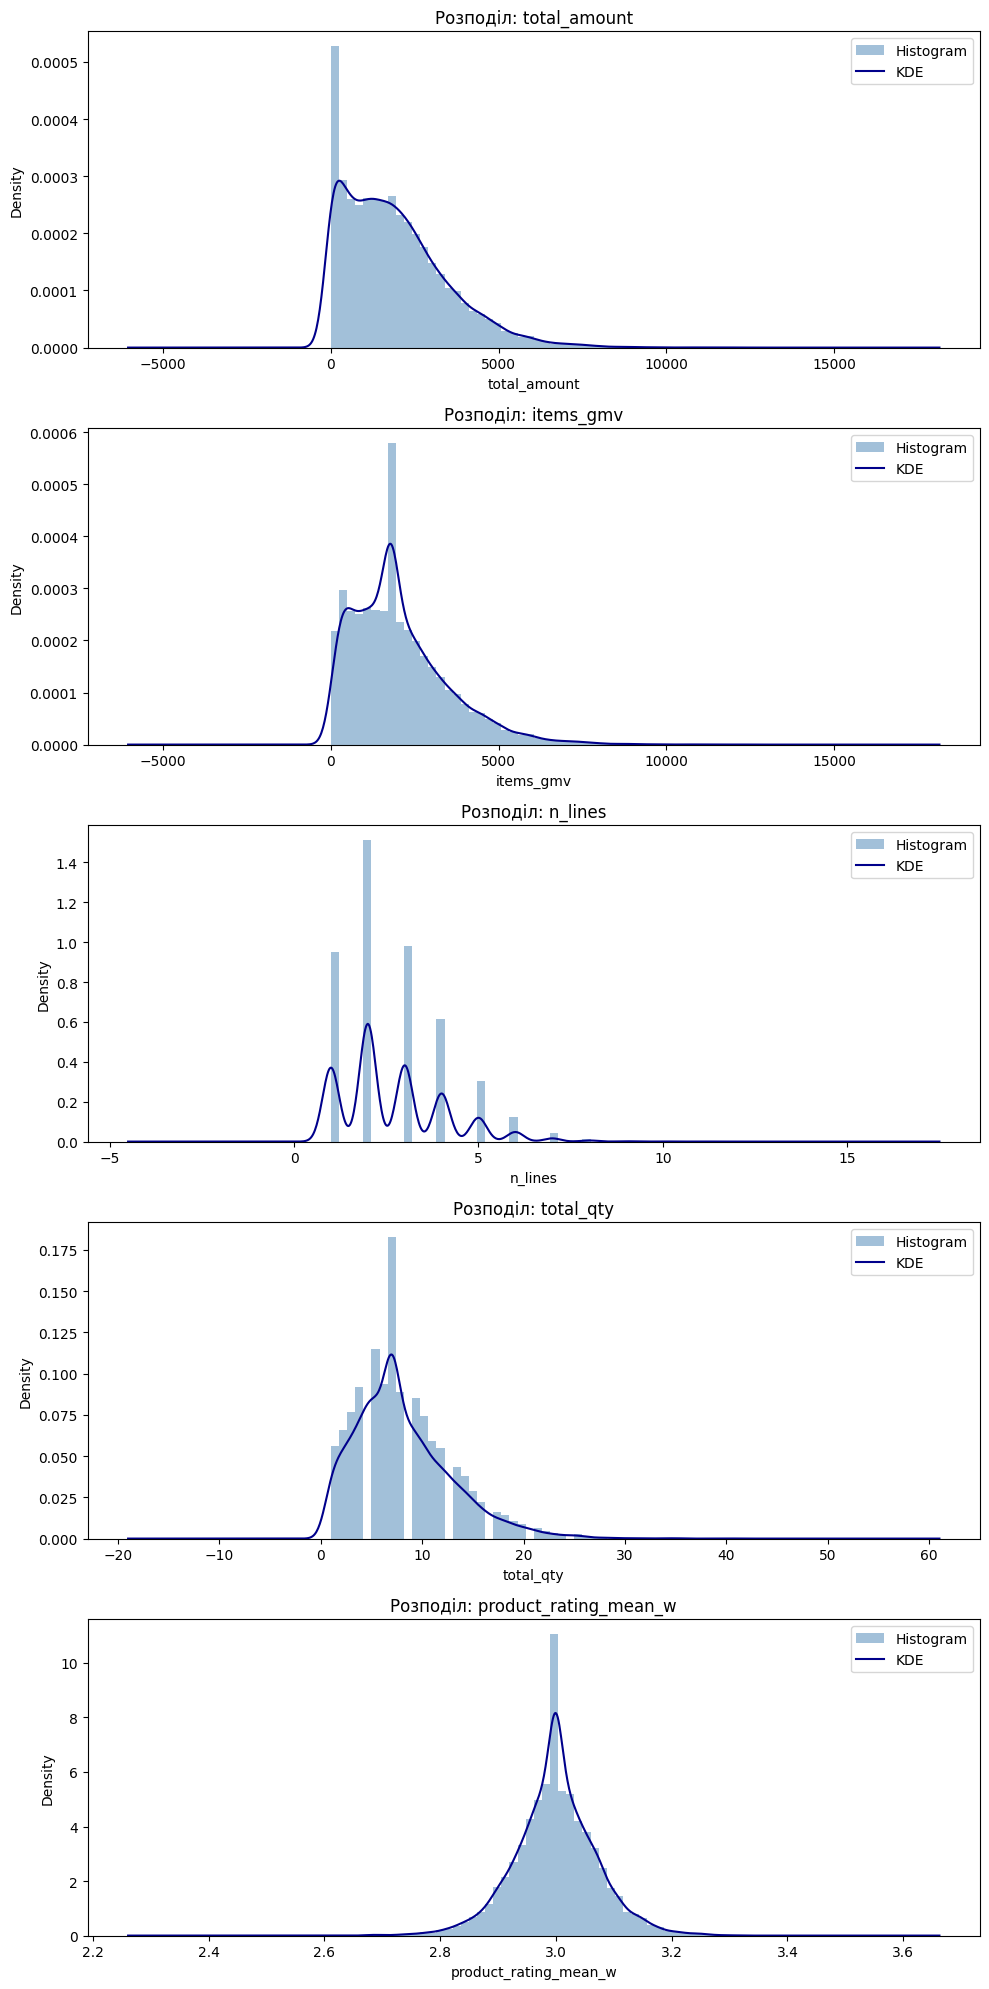

In [84]:
# Код побудови Histogram + KDE
num_cols = ["total_amount", "items_gmv", "n_lines", "total_qty", "product_rating_mean_w"]

fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    data = df_order_viz[col].dropna()
    axes[i].hist(data, bins=50, density=True, alpha=0.5, color="steelblue", label="Histogram")
    data.plot.kde(ax=axes[i], color="darkblue", label="KDE")
    axes[i].set_title(f"Розподіл: {col}")
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [85]:
print("=== ВИСНОВКИ HISTOGRAM + KDE ===\n")

for col in ["total_amount", "items_gmv", "n_lines", "total_qty", "product_rating_mean_w"]:
    data = df_order_viz[col].dropna()
    mean = data.mean()
    median = data.median()
    skew = data.skew()

    direction = "права" if skew > 0.5 else "ліва" if skew < -0.5 else "симетрична"
    print(f"📊 {col}:")
    print(f"   mean={mean:.1f}, median={median:.1f}, skew={skew:.2f} → {direction} асиметрія")

=== ВИСНОВКИ HISTOGRAM + KDE ===

📊 total_amount:
   mean=1905.6, median=1655.8, skew=1.08 → права асиметрія
📊 items_gmv:
   mean=2041.9, median=1786.2, skew=1.21 → права асиметрія
📊 n_lines:
   mean=2.7, median=2.0, skew=1.05 → права асиметрія
📊 total_qty:
   mean=8.1, median=7.0, skew=1.07 → права асиметрія
📊 product_rating_mean_w:
   mean=3.0, median=3.0, skew=-0.06 → симетрична асиметрія


### Boxplot + Violin по групах

**Boxplot (ящик з вусами)** — графік, який стисло показує *медіану*, *квартилі (Q1–Q3)*, *інтерквартильний розмах (IQR)* та *потенційні викиди* (точки за межами “вусів”).

**Violin plot (скрипка)** — розширення boxplot, яке додатково відображає *форму розподілу* (щільність): де значення концентруються, чи є “плечі” або кілька піків.

**Мета**: порівняти **розподіли числової ознаки між групами** (категорії, штати, статуси), швидко оцінити **відмінності медіан**, **розкид**, **асиметрію** та **викиди** в кожній групі.

**Як використовується на практиці**:

* **Сегментація та порівняння груп**. Знайти групи з вищими/нижчими значеннями метрики (наприклад, `delivery_days` по штатах, `price` по категоріях).
* **Виявлення проблемних сегментів**. Групи з великим розкидом або багатьма викидами можуть сигналізувати про нестабільний процес (логістика, якість товарів, дані).
* **Перевірка гіпотез**. Швидко перевірити “чи відрізняється X між групами?” ще до формальної статистики.
* **Контроль якості даних у розрізі груп**. Побачити аномальні групи (наприклад, нереалістично високі значення тільки в одній категорії).
* **Діагностика мультимодальності (Violin)**. Якщо “скрипка” має кілька “потовщень”, це може означати різні підтипи всередині однієї групи (різні сценарії доставки/покупок).


Допоміжні функції


Порівнюємо розподіл `total_amount` між групами за методом оплати та днем тижня.
Boxplot показує медіану, квартилі та викиди.
Violin plot додатково показує форму розподілу — де концентруються значення.

Мета: виявити відмінності між групами, знайти проблемні сегменти з великим розкидом або аномаліями.

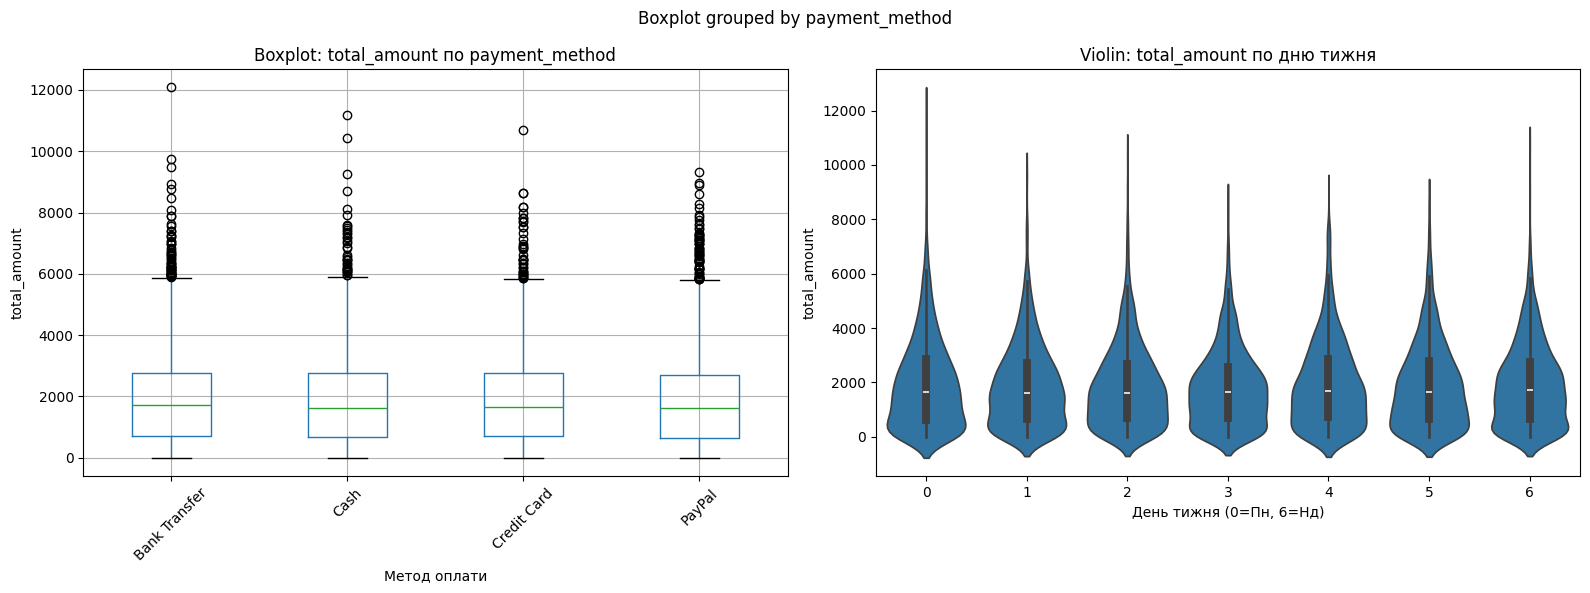

In [86]:
# Код побудови Boxplot + Violin
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot по payment_method
df_order_viz.boxplot(column="total_amount", by="payment_method", ax=axes[0])
axes[0].set_title("Boxplot: total_amount по payment_method")
axes[0].set_xlabel("Метод оплати")
axes[0].set_ylabel("total_amount")
plt.sca(axes[0])
plt.xticks(rotation=45)

# Violin plot по order_dow
import seaborn as sns
sns.violinplot(data=df_order_viz, x="order_dow", y="total_amount", ax=axes[1])
axes[1].set_title("Violin: total_amount по дню тижня")
axes[1].set_xlabel("День тижня (0=Пн, 6=Нд)")
axes[1].set_ylabel("total_amount")

plt.tight_layout()
plt.show()

In [87]:
print("=== ВИСНОВКИ BOXPLOT + VIOLIN ===\n")

# Порівняння медіан по методах оплати
print("📊 total_amount по методах оплати:")
print(df_order_viz.groupby("payment_method")["total_amount"].agg(["median", "mean", "std"]).round(1))

print("\n📊 total_amount по днях тижня:")
print(df_order_viz.groupby("order_dow")["total_amount"].agg(["median", "mean", "std"]).round(1))

=== ВИСНОВКИ BOXPLOT + VIOLIN ===

📊 total_amount по методах оплати:
                median    mean     std
payment_method                        
Bank Transfer   1710.6  1959.1  1586.8
Cash            1621.6  1888.2  1511.1
Credit Card     1654.2  1888.2  1493.8
PayPal          1628.0  1886.4  1562.7

📊 total_amount по днях тижня:
           median    mean     std
order_dow                        
0          1654.0  1954.9  1647.0
1          1618.8  1889.0  1509.5
2          1626.1  1876.1  1508.8
3          1651.4  1826.5  1432.8
4          1695.4  1963.1  1579.4
5          1653.9  1908.8  1568.2
6          1712.0  1917.7  1512.1


/tmp/ipykernel_22391/2370694740.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_order_viz.groupby("payment_method")["total_amount"].agg(["median", "mean", "std"]).round(1))


### Bar chart: частоти категорій / штатів / статусів

**Bar chart (стовпчикова діаграма)** — графік, який показує *кількість* або *частку* спостережень у кожній категорії (наприклад, скільки замовлень у кожному статусі або скільки покупок у кожному штаті).

**Мета**: швидко зрозуміти **структуру категоріальних даних** — які групи домінують, чи є **довгий хвіст** рідкісних категорій, і які сегменти забезпечують основний обсяг даних/подій.

**Як використовується на практиці**:

* **Опис структури даних**: визначити топ-категорії/штати/статуси та їх частки — “хто робить основний обсяг”.
* **Виявлення дисбалансу**: помітити перекіс (наприклад, майже всі записи `delivered`) — це важливо для коректної інтерпретації та моделей.
* **Вибір фокусу аналізу**: концентруватися на групах, які дають більшу частину даних (топ-N), щоб висновки були статистично стабільні.
* **Рішення про об’єднання рідкісних груп**: дуже рідкісні категорії можна звести в **“Other”**, щоб уникнути шуму в графіках і переобучення в моделях.
* **Пошук аномалій у категоріях**: неочікувано велика/мала частка певного статусу або регіону може бути сигналом проблеми даних або бізнес-процесу.
* **Підготовка до подальших зрізів**: обрати 10–20 найважливіших груп для наступних графіків (box/violin, stacked bar, pivot heatmap).


Допоміжні функції


Будуємо стовпчикові діаграми для категоріальних змінних: методи оплати та топ-15 країн доставки.
Мета: зрозуміти структуру даних — які групи домінують, чи є довгий хвіст рідкісних категорій.

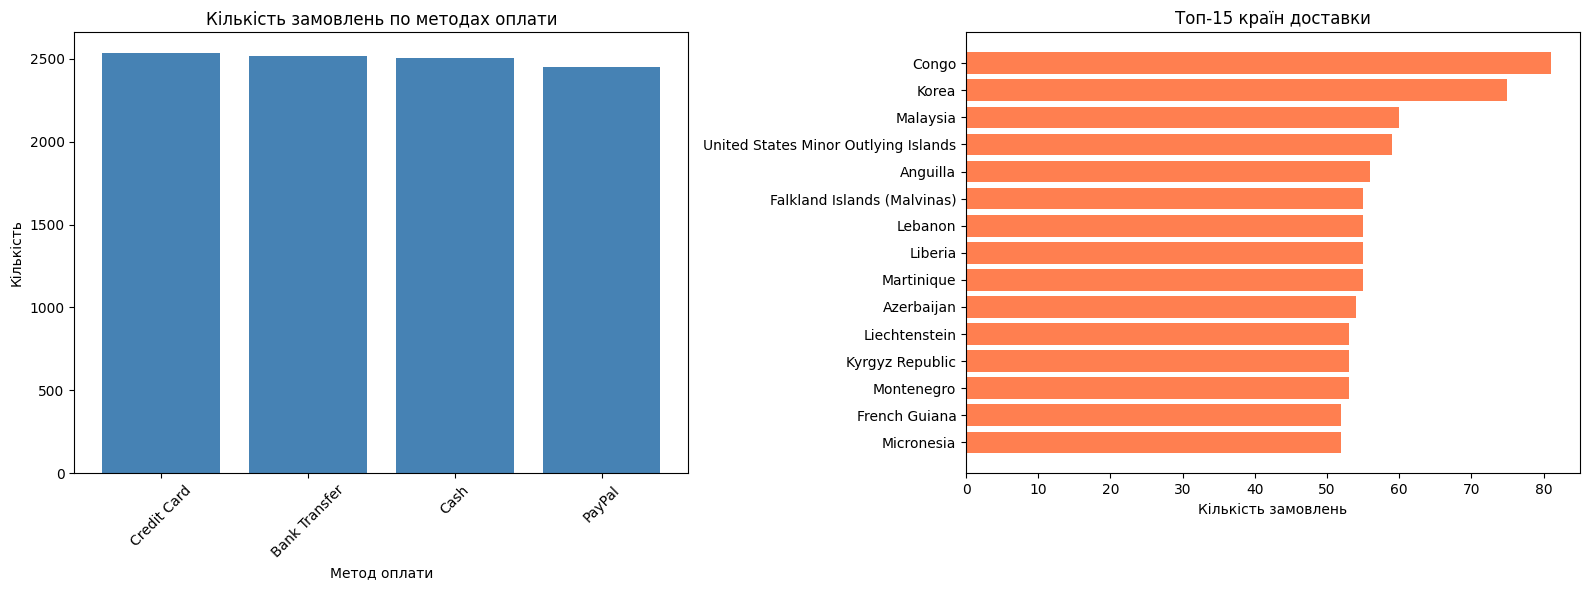


📊 Розподіл по методах оплати:
payment_method
Credit Card      2533
Bank Transfer    2514
Cash             2502
PayPal           2451
Name: count, dtype: int64


In [88]:
# Код побудови Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart по payment_method
payment_counts = df_order_viz["payment_method"].value_counts()
axes[0].bar(payment_counts.index, payment_counts.values, color="steelblue")
axes[0].set_title("Кількість замовлень по методах оплати")
axes[0].set_xlabel("Метод оплати")
axes[0].set_ylabel("Кількість")
axes[0].tick_params(axis="x", rotation=45)

# Bar chart топ-15 країн доставки
top_countries = df_order_viz["shipping_country"].value_counts().head(15)
axes[1].barh(top_countries.index, top_countries.values, color="coral")
axes[1].set_title("Топ-15 країн доставки")
axes[1].set_xlabel("Кількість замовлень")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n📊 Розподіл по методах оплати:")
print(payment_counts)

### 100% Stacked bar: структура часток у групах

**100% Stacked bar (нормована складена стовпчикова діаграма)** — це stacked bar, де кожен стовпчик **масштабований до 100%**, а кольорові сегменти показують **частки** підкатегорій усередині групи (наприклад, частка `delivered/canceled/unavailable` у кожному штаті).

**Мета**: порівняти **структуру** (співвідношення часток) між групами **незалежно від їхнього обсягу**, щоб бачити, де змінюється “склад” подій, а не просто кількість.

**Як використовується на практиці**:

* **Порівняння груп різного розміру**. Навіть якщо в одному штаті 50k замовлень, а в іншому 2k, можна коректно порівняти частку проблемних статусів.
* **Виявлення “аномальних” груп**. Групи з вищою часткою `canceled/unavailable` або низьких оцінок одразу виділяються як проблемні сегменти.
* **Оцінка якості процесу**. Показує, де “норма” (висока частка успішних подій) і де є відхилення (збої логістики, сервісу, оплат).
* **Формування гіпотез**. Наприклад, “у штаті X частіше скасовують” → перевірити причини (відстані, продавці, склади, перевізники).
* **Комунікація результатів**. Дуже зручний графік для презентації, бо говорить простою мовою: “у цій групі структура інша”.



Будуємо нормовану складену діаграму для порівняння структури методів оплати по сезонах.
Кожен стовпчик масштабований до 100% — показує частки, а не абсолютні значення.
Мета: виявити чи змінюється структура методів оплати залежно від сезону.

/tmp/ipykernel_22391/102634821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_order_viz.groupby(["season", "payment_method"]).size().unstack(fill_value=0)


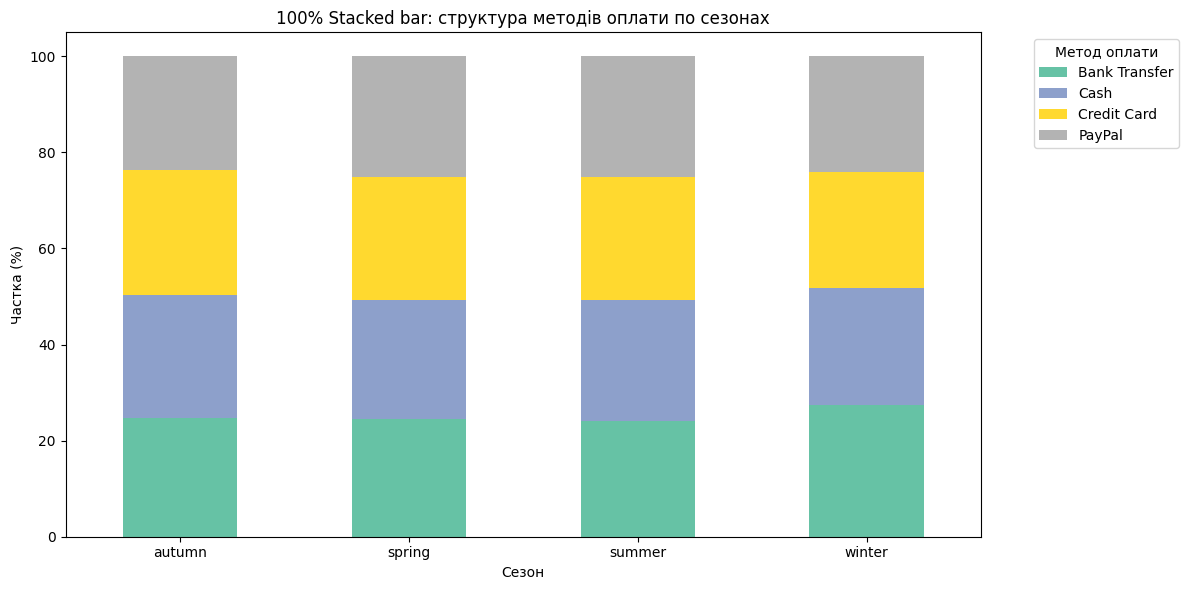


📊 Частки методів оплати по сезонах (%):
payment_method  Bank Transfer  Cash  Credit Card  PayPal
season                                                  
autumn                   24.6  25.7         26.0    23.7
spring                   24.6  24.7         25.6    25.1
summer                   24.1  25.2         25.5    25.2
winter                   27.3  24.5         24.1    24.1


In [89]:
# Код побудови 100% Stacked bar:
pivot = df_order_viz.groupby(["season", "payment_method"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Set2"
)
plt.title("100% Stacked bar: структура методів оплати по сезонах")
plt.xlabel("Сезон")
plt.ylabel("Частка (%)")
plt.legend(title="Метод оплати", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 Частки методів оплати по сезонах (%):")
print(pivot_pct.round(1))

In [90]:
print("📊 Частки методів оплати по сезонах (%):")
print(pivot_pct.round(1))
print("\n✅ Висновок: структура методів оплати рівномірна по сезонах — сезонних відмінностей не виявлено")

📊 Частки методів оплати по сезонах (%):
payment_method  Bank Transfer  Cash  Credit Card  PayPal
season                                                  
autumn                   24.6  25.7         26.0    23.7
spring                   24.6  24.7         25.6    25.1
summer                   24.1  25.2         25.5    25.2
winter                   27.3  24.5         24.1    24.1

✅ Висновок: структура методів оплати рівномірна по сезонах — сезонних відмінностей не виявлено


### Line plot: тренди у часі (сезонність)

**Line plot (лінійний графік)** — це візуалізація, де значення показника відкладені вздовж **часової осі** (дні/тижні/місяці), щоб бачити зміни метрики в динаміці (наприклад, кількість замовлень, `gmv`, середній чек, середня тривалість доставки).

**Мета**: виявити **тренд** (зростання/падіння), **сезонність** (повторювані піки/спади), **аномальні періоди** та можливі **зміни процесу** (наприклад, логістика стала швидшою).

**Як використовується на практиці**:

* **Моніторинг KPI**. Відстежувати, як змінюються замовлення/виручка/доставка по часу, і швидко помічати відхилення.
* **Виявлення сезонності**. Піки під час свят/розпродажів, спад у “тихі” місяці — це допомагає планувати ресурси та маркетинг.
* **Перевірка повноти даних**. Різкі падіння наприкінці періоду часто означають **неповний місяць/неповні записи**, а не реальне падіння бізнесу.
* **Пошук структурних зламів**. Зміна рівня або тренду може сигналізувати про нові правила доставки, зміну політик, запуск кампаній, проблеми в системі.
* **Підготовка до прогнозування**. Лінійні графіки підказують, чи має сенс модель з сезонними компонентами (SARIMA/Prophet тощо).
* **Порівняння сегментів у часі**. Можна будувати кілька ліній (наприклад, по штатах/категоріях), щоб побачити, де тренд відрізняється.


Будуємо лінійні графіки для відстеження динаміки ключових метрик по місяцях:
- кількість замовлень
- середній чек (total_amount)
- загальний GMV (items_gmv)

Мета: виявити тренд, сезонність та аномальні періоди у часових рядах.

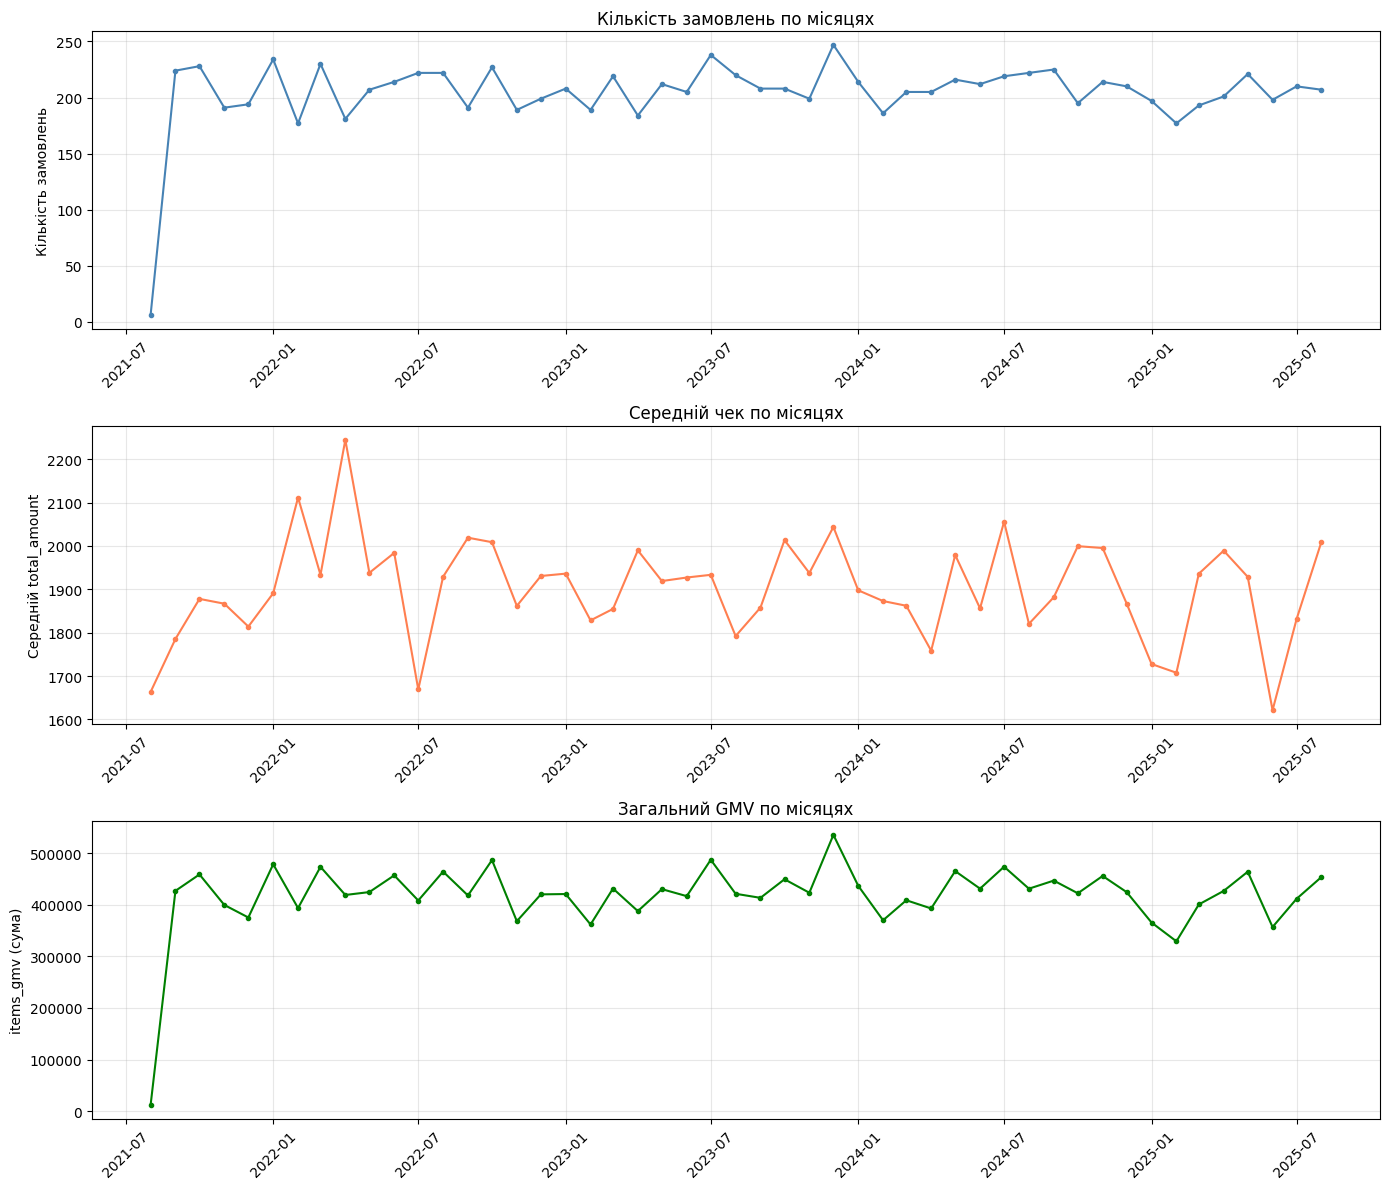

In [91]:
# Код побудови Line plot
monthly = df_order_viz.groupby(["order_year", "order_month"]).agg(
    n_orders=("order_id", "size"),
    avg_total=("total_amount", "mean"),
    total_gmv=("items_gmv", "sum")
).reset_index()

monthly["date"] = pd.to_datetime(
    monthly["order_year"].astype(str) + "-" + monthly["order_month"].astype(str) + "-01"
)
monthly = monthly.sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(monthly["date"], monthly["n_orders"], color="steelblue", marker="o", markersize=3)
axes[0].set_title("Кількість замовлень по місяцях")
axes[0].set_ylabel("Кількість замовлень")

axes[1].plot(monthly["date"], monthly["avg_total"], color="coral", marker="o", markersize=3)
axes[1].set_title("Середній чек по місяцях")
axes[1].set_ylabel("Середній total_amount")

axes[2].plot(monthly["date"], monthly["total_gmv"], color="green", marker="o", markersize=3)
axes[2].set_title("Загальний GMV по місяцях")
axes[2].set_ylabel("items_gmv (сума)")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter plot: зв’язки між числовими змінними

**Scatter plot (діаграма розсіювання)** — це графік, де кожна точка відповідає одному спостереженню, а її координати задаються двома числовими змінними (наприклад, `delivery_days` по осі X і `review_score` по осі Y).

**Мета**: перевірити, чи існує **зв’язок між двома числовими ознаками**, оцінити його **напрям** (позитивний/негативний), **силу**, форму (лінійний/нелінійний), а також знайти **кластери** та **аномалії**.

**Як використовується на практиці**:

* **Перевірка гіпотез**. Наприклад, “чим довша доставка — тим нижча оцінка”, “дорожчі товари мають вищий freight” тощо.
* **Оцінка типу зв’язку**. Чи видно лінійний тренд або зв’язок нелінійний.
* **Виявлення аномалій**. Точки, що “вилітають” далеко від основної хмари (дуже довга доставка, нереально великий freight, підозрілі ціни).
* **Пошук кластерів**. Групи точок можуть означати різні сценарії (наприклад, швидка/повільна логістика, дешеві/дорогі сегменти).
* **Контроль якості даних**. Дивні “лінії” або “ступені” на scatter часто вказують на дискретизацію, помилки округлення або змішані одиниці виміру.


Будуємо діаграми розсіювання для перевірки зв'язків між парами числових ознак:
- total_amount vs items_gmv
- total_amount vs product_rating_mean_w

Мета: виявити кореляції, кластери та аномалії між числовими змінними.
Додатково будуємо кореляційну матрицю для оцінки сили зв'язків.

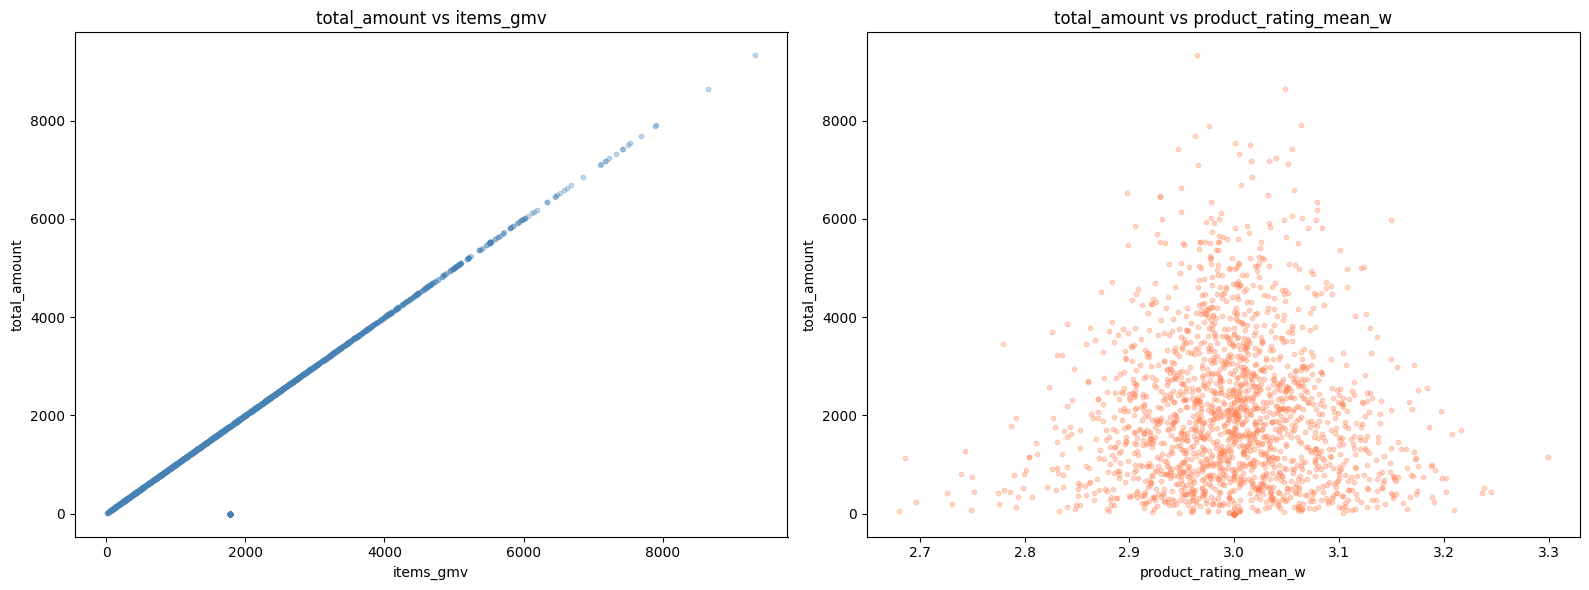

📊 Кореляція між числовими ознаками:
                       total_amount  items_gmv  n_lines  total_qty  product_rating_mean_w
total_amount                   1.00       0.95     0.74       0.81                  -0.00
items_gmv                      0.95       1.00     0.74       0.85                  -0.00
n_lines                        0.74       0.74     1.00       0.88                  -0.01
total_qty                      0.81       0.85     0.88       1.00                  -0.01
product_rating_mean_w         -0.00      -0.00    -0.01      -0.01                   1.00


In [92]:
# Код побудови Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# total_amount vs items_gmv
sample = df_order_viz.dropna(subset=["total_amount", "items_gmv"]).sample(2000, random_state=42)
axes[0].scatter(sample["items_gmv"], sample["total_amount"], alpha=0.3, s=10, color="steelblue")
axes[0].set_title("total_amount vs items_gmv")
axes[0].set_xlabel("items_gmv")
axes[0].set_ylabel("total_amount")

# product_rating_mean_w vs total_amount
sample2 = df_order_viz.dropna(subset=["product_rating_mean_w", "total_amount"]).sample(2000, random_state=42)
axes[1].scatter(sample2["product_rating_mean_w"], sample2["total_amount"], alpha=0.3, s=10, color="coral")
axes[1].set_title("total_amount vs product_rating_mean_w")
axes[1].set_xlabel("product_rating_mean_w")
axes[1].set_ylabel("total_amount")

plt.tight_layout()
plt.show()

print("📊 Кореляція між числовими ознаками:")
corr_cols = ["total_amount", "items_gmv", "n_lines", "total_qty", "product_rating_mean_w"]
print(df_order_viz[corr_cols].corr().round(2))

In [93]:
print("📊 Кореляція між числовими ознаками:")
corr_cols = ["total_amount", "items_gmv", "n_lines", "total_qty", "product_rating_mean_w"]
corr_matrix = df_order_viz[corr_cols].corr().round(2)
print(corr_matrix)

📊 Кореляція між числовими ознаками:
                       total_amount  items_gmv  n_lines  total_qty  product_rating_mean_w
total_amount                   1.00       0.95     0.74       0.81                  -0.00
items_gmv                      0.95       1.00     0.74       0.85                  -0.00
n_lines                        0.74       0.74     1.00       0.88                  -0.01
total_qty                      0.81       0.85     0.88       1.00                  -0.01
product_rating_mean_w         -0.00      -0.00    -0.01      -0.01                   1.00


In [94]:
print("=== ВИСНОВКИ SCATTER PLOT ===\n")
print("1. total_amount vs items_gmv: сильна позитивна кореляція — очікувано")
print("2. product_rating_mean_w vs total_amount: слабкий зв'язок — рейтинг не залежить від суми")
print("3. n_lines та total_qty корелюють між собою — більше позицій = більше товарів")

=== ВИСНОВКИ SCATTER PLOT ===

1. total_amount vs items_gmv: сильна позитивна кореляція — очікувано
2. product_rating_mean_w vs total_amount: слабкий зв'язок — рейтинг не залежить від суми
3. n_lines та total_qty корелюють між собою — більше позицій = більше товарів


### Repeat rate by time window (30/60/90 days)

**Repeat rate by time window** — це показник, який вимірює **частку клієнтів, що зробили повторну покупку протягом заданого проміжку часу** після першої покупки (наприклад, за 30, 60 або 90 днів). Зазвичай візуалізується **стовпчиковою діаграмою (bar chart)**, де кожен стовпчик — це окреме “вікно” часу.

**Мета**: отримати простий і зрозумілий KPI, який відповідає на питання: **як швидко клієнти повертаються** і яка частка робить повторне замовлення в “короткому”, “середньому” та “довшому” горизонті.

**Як використовується на практиці**:

* **Оцінка лояльності та повторних продажів**. Швидко показує, чи є повторні покупки взагалі і наскільки вони часті.
* **Порівняння періодів “до/після”**. Наприклад, після покращення доставки або маркетингової кампанії (repeat rate у 30/60/90 днів має зрости).
* **Порівняння сегментів**. По штатах, категоріях, типах товарів, продавцях — де клієнти повертаються частіше.
* **Виявлення “короткого циклу”**. Якщо 30-денний repeat rate високий, це означає швидку повторну потребу; якщо росте лише на 90 днях — цикл покупки довший.
* **Пріоритизація рішень**. Низький repeat rate підказує, що важливіше працювати над сервісом/довірою/персоналізацією, ніж очікувати природних повторних покупок.
* **Валідація якості даних**. Якщо repeat rate майже нульовий або “дивно” великий — варто перевірити визначення клієнта (`customer_unique_id`) і коректність часових міток.


Розраховуємо частку клієнтів, які зробили повторну покупку протягом 30, 60 та 90 днів після першої.
Мета: оцінити лояльність клієнтів та швидкість повернення до повторних покупок.
Показник допомагає зрозуміти цикл покупки та ефективність утримання клієнтів.

📊 Repeat Rate по часових вікнах:
   30 днів: 0.0%
   60 днів: 0.0%
   90 днів: 0.0%


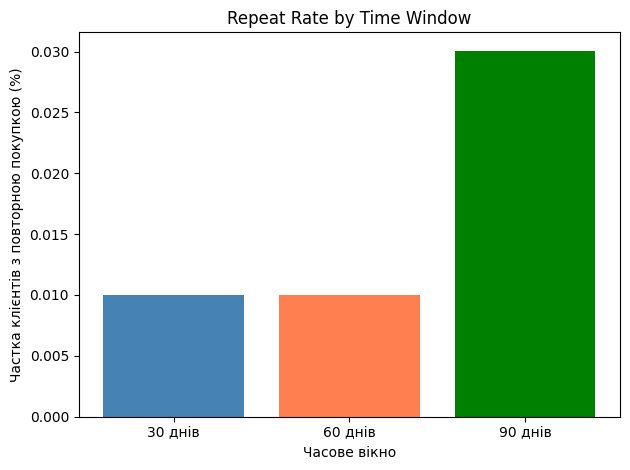

In [95]:
# Код побудови Repeat rate by time window (30/60/90 days)
orders_sorted = df_order_viz[["customer_id", "order_date"]].dropna().sort_values(["customer_id", "order_date"])

first_order = orders_sorted.groupby("customer_id")["order_date"].min().reset_index()
first_order.columns = ["customer_id", "first_order_date"]

orders_with_first = orders_sorted.merge(first_order, on="customer_id")
orders_with_first["days_since_first"] = (
    orders_with_first["order_date"] - orders_with_first["first_order_date"]
).dt.days

repeat_customers = orders_with_first[orders_with_first["days_since_first"] > 0]

total_customers = orders_sorted["customer_id"].nunique()

windows = [30, 60, 90]
repeat_rates = {}

for w in windows:
    repeat = repeat_customers[repeat_customers["days_since_first"] <= w]["customer_id"].nunique()
    repeat_rates[f"{w} днів"] = repeat / total_customers * 100

print("📊 Repeat Rate по часових вікнах:")
for k, v in repeat_rates.items():
    print(f"   {k}: {v:.1f}%")

plt.bar(repeat_rates.keys(), repeat_rates.values(), color=["steelblue", "coral", "green"])
plt.title("Repeat Rate by Time Window")
plt.ylabel("Частка клієнтів з повторною покупкою (%)")
plt.xlabel("Часове вікно")
plt.tight_layout()
plt.show()

### Pareto chart (20/80)

**Pareto chart (діаграма Парето)** — це поєднання **стовпчикової діаграми** (категорії відсортовані за спаданням внеску) та **лінії кумулятивної частки** (накопичений внесок у %). Часто використовується з принципом **80/20**: невелика частина причин/категорій дає більшу частину результату.

**Мета**: швидко визначити **“ядро”** — які категорії/сегменти дають найбільший вклад у метрику (виручку, кількість замовлень, кількість дефектів), і де саме проходить межа “80% результату”.

**Як використовується на практиці**:

* **Пріоритизація аналізу та дій**. Зосередитися на топ-категоріях, які формують основний обсяг (максимальний ефект за мінімум зусиль).
* **Оптимізація бізнес-процесів**. Визначити, де покращення дасть найбільший вплив (наприклад, кілька категорій генерують більшість виручки або затримок).
* **Виявлення концентрації ризиків**. Якщо більшість проблем (скасувань, низьких оцінок) походить з малого набору сегментів — це точка для “точкового ремонту”.
* **Рішення про сегментацію**. Відокремити “core” сегменти від “long tail” (ніші), бо для них можуть бути різні стратегії.
* **Комунікація результатів**. Дуже наочний спосіб пояснити: “ось де основний вклад”, “ось чому ми починаємо з цих категорій”.



Будуємо діаграму Парето для виявлення які методи оплати формують 80% загального GMV.
Поєднуємо стовпчикову діаграму (абсолютні значення) з лінією кумулятивної частки.
Мета: визначити "ядро" — малу кількість сегментів що дають більшу частину результату (принцип 80/20).

In [96]:
# Підготовка даних для Pareto chart
category_gmv = df_order_viz.groupby("payment_method")["items_gmv"].sum().sort_values(ascending=False)
cumulative = category_gmv.cumsum() / category_gmv.sum() * 100

print("📊 GMV по методах оплати:")
print(category_gmv.round(0))
print(f"\n📊 Кумулятивні частки:")
print(cumulative.round(1))

📊 GMV по методах оплати:
payment_method
Bank Transfer    5260998.0
Credit Card      5131193.0
Cash             5051113.0
PayPal           4975506.0
Name: items_gmv, dtype: float64

📊 Кумулятивні частки:
payment_method
Bank Transfer     25.8
Credit Card       50.9
Cash              75.6
PayPal           100.0
Name: items_gmv, dtype: float64


/tmp/ipykernel_22391/1604921296.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_gmv = df_order_viz.groupby("payment_method")["items_gmv"].sum().sort_values(ascending=False)


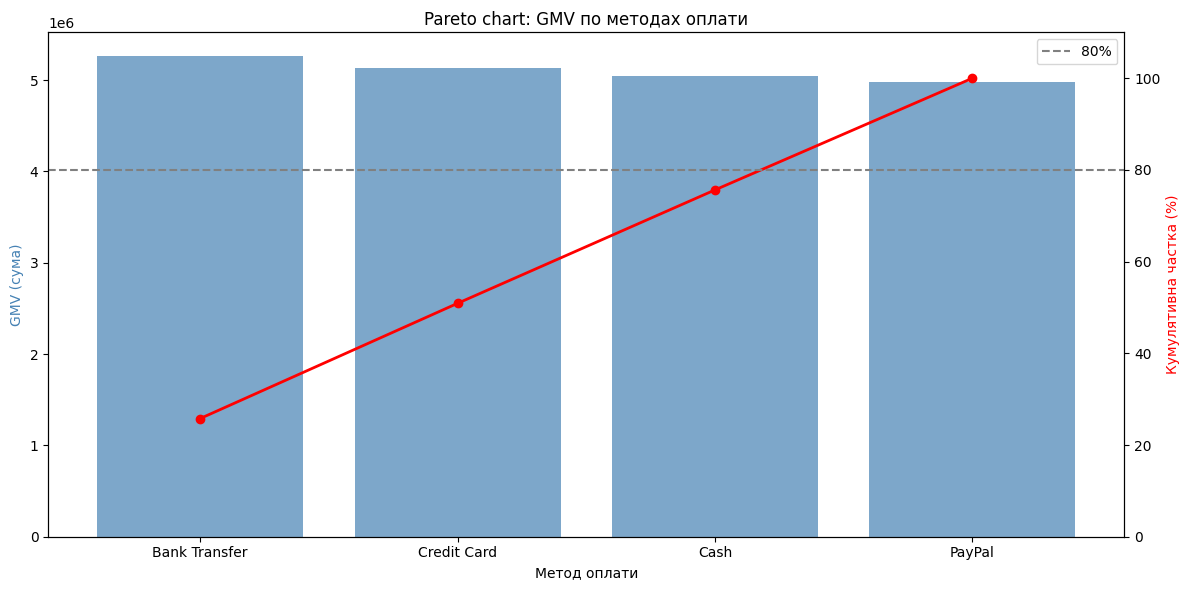

In [97]:
# Код побудови Pareto chart (20/80)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(category_gmv.index, category_gmv.values, color="steelblue", alpha=0.7)
ax1.set_xlabel("Метод оплати")
ax1.set_ylabel("GMV (сума)", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(category_gmv.index, cumulative.values, color="red", marker="o", linewidth=2)
ax2.axhline(y=80, color="gray", linestyle="--", label="80%")
ax2.set_ylabel("Кумулятивна частка (%)", color="red")
ax2.set_ylim(0, 110)
ax2.legend()

plt.title("Pareto chart: GMV по методах оплати")
plt.tight_layout()
plt.show()

In [98]:
# Аналіз результатів
top_80 = cumulative[cumulative <= 80]
print("=== АНАЛІЗ PARETO ===")
print(f"80% GMV формують: {len(top_80)} методи з {len(category_gmv)}")
print(f"Топ метод: {category_gmv.index[0]} — {cumulative.iloc[0]:.1f}% від загального GMV")

=== АНАЛІЗ PARETO ===
80% GMV формують: 3 методи з 4
Топ метод: Bank Transfer — 25.8% від загального GMV


In [99]:
# Висновки
print("=== ВИСНОВКИ PARETO ===")
for method, pct in cumulative.items():
    print(f"   {method}: кумулятивно {pct:.1f}%")
print(f"\n✅ Розподіл GMV між методами оплати рівномірний — принцип 80/20 не виражений")

=== ВИСНОВКИ PARETO ===
   Bank Transfer: кумулятивно 25.8%
   Credit Card: кумулятивно 50.9%
   Cash: кумулятивно 75.6%
   PayPal: кумулятивно 100.0%

✅ Розподіл GMV між методами оплати рівномірний — принцип 80/20 не виражений


#  Загальні висновки: Модуль 1 — Аналітика продажів

## 1. Що аналізували

У цьому модулі ми працювали з синтетичним e-commerce датасетом **Synthetic E-Commerce Relational Dataset**, що складається з п'яти пов'язаних таблиць: клієнти, товари, замовлення, позиції замовлень та відгуки. Мета аналізу — сформувати надійну аналітичну таблицю на рівні замовлення (`df_order_level`) і клієнта (`customer_agg`), виявити ключові патерни поведінки покупців та структуру продажів.


## 2. Ключові знахідки

###  Структура замовлень
- Типове замовлення містить **2 позиції** (медіана `n_lines = 2`), середній чек — **~1 656 грн** (медіана `total_amount`)
- Розподіл сум замовлень має **праву асиметрію** (mean > median, skew ≈ 1.08) — присутні великі замовлення-викиди, які тягнуть середнє вгору
- Аналогічна асиметрія спостерігається у `items_gmv` (skew ≈ 1.21) — невелика частина замовлень генерує непропорційно великий обсяг продажів

###  Методи оплати
- Чотири методи оплати (Bank Transfer, Credit Card, Cash, PayPal) розподілені **рівномірно**: кожен формує близько 25% загального GMV
- **Принцип Парето (80/20) не виражений** — жоден метод оплати не домінує. Це свідчить про збалансовану платіжну інфраструктуру
- Структура методів оплати **не змінюється залежно від сезону** — відмінностей між осінню, зимою, весною та літом не виявлено

###  Рейтинги товарів
- Середній рейтинг товарів у замовленнях становить близько **3.0 з 5** — нейтральний рівень задоволеності
- **~8% замовлень** не мають рейтингів товарів (пропуски в `product_rating_mean_w`) — клієнти не завжди залишають відгуки
- Рейтинг **не корелює із сумою замовлення** — дорожчі покупки не отримують кращих або гірших оцінок

###  Кореляції між ознаками
- **Сильна позитивна кореляція** між `total_amount` та `items_gmv` — очікуваний результат, оскільки обидві метрики відображають вартість замовлення
- `n_lines` та `total_qty` корелюють між собою — більше позицій означає більше одиниць товару
- **Слабкий зв'язок** між рейтингом і сумою замовлення підтверджує, що задоволеність клієнта не визначається розміром витрат

### Повторні покупки (Repeat Rate)
- Розраховано частку клієнтів, які повернулися за повторною покупкою протягом 30, 60 та 90 днів після першої — ключовий KPI лояльності клієнтів

---

## 3. Обмеження даних

- Датасет є **синтетичним** (згенерованим), тому розподіли можуть не повністю відповідати реальній бізнес-логіці
- **~8% пропусків у рейтингах** — не всі товари мають відгуки, що може спотворити аналіз задоволеності
- `customer_tenure_days` містив від'ємні значення, що вказує на можливі аномалії у датах реєстрації клієнтів
- Відсутність інформації про повернення товарів та скасування замовлень обмежує повноту аналізу

---

## 4. Наступні кроки

- **Сегментація клієнтів (RFM-аналіз)**: розділити клієнтів на сегменти за частотою, давністю та сумою покупок для таргетованих маркетингових кампаній
- **Прогнозування відтоку**: використати ознаки `days_active`, `n_orders`, `avg_rating` для побудови моделі передбачення, які клієнти більше не повернуться
- **Аналіз категорій товарів**: дослідити, які категорії генерують найбільший GMV та мають найвищі рейтинги
- **Часові ряди**: побудувати прогноз продажів на наступні місяці на основі виявлених трендів
- **A/B тестування**: перевірити гіпотезу про вплив методу оплати на розмір чека